# Part 0 — Setup & Imports

This notebook accompanies the written report for the EMIF group project and is organized to reproduce all results in a transparent, step-by-step manner. The research question is: **"How do oil price increases transmit across asset classes — equities, government bonds, credit markets, and gold — and can we build a forecasting framework to anticipate these multi-asset effects?"**

The notebook covers data loading, descriptive analysis, stationarity and cointegration tests, VAR estimation, structural analysis (IRFs, FEVD, Granger causality), asymmetric effects, regime analysis, out-of-sample forecasting, and a portfolio stress test. Each section corresponds to a dedicated section of the written report.

**Libraries used:**
- `numpy` — numerical computation and array operations
- `pandas` — data loading, manipulation, and time-series resampling
- `matplotlib` / `seaborn` — visualization (time-series plots, IRF charts, heatmaps)
- `scipy` — statistical tests (Jarque-Bera, Ljung-Box)
- `statsmodels` — ARMA, ADF, KPSS, Johansen cointegration, VAR/VECM estimation

All results are produced from the single data file `data/data_hec_projet_1.xlsx` which contains three sheets: **Daily**, **Monthly**, and **Quarterly**.

In [1]:
# Core stack
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Time-series econometrics
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Display settings
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.figsize"] = (12, 5)


---

# Part 1 — Data Loading & Cleaning

## 1.1 — Load the Excel File

We load all three sheets from `data_hec_projet_1.xlsx`: **Daily** (Jan 1990 – Mar 2026), **Monthly** (Dec 1989 – Feb 2026), and **Quarterly** (Dec 1989 – Dec 2025). The file is located automatically at runtime using `pathlib.rglob`, so it works regardless of whether it sits at the project root or in a subdirectory. The Excel file contains metadata in rows 1–5; actual data begins at row 6, so we skip the first 5 rows when reading. Dates are parsed explicitly and set as the DataFrame index. The Daily sheet contains: WTI futures, Brent futures, BCOM Energy, TFT futures, Natural Gas futures, S&P 500, MSCI World, MSCI EM, Russell 2000, US 10Y Rate, US 2Y Rate, HY Yield-to-Worst, and Gold.

In [2]:
from pathlib import Path

# Search for the data file anywhere under the notebook's working directory.
# Works whether the file sits at the project root, in data/, or anywhere else.
_matches = list(Path().resolve().rglob("data_hec_projet_1.xlsx"))

if not _matches:
    raise FileNotFoundError(
        "Could not find 'data_hec_projet_1.xlsx'.\n"
        f"Searched under: {Path().resolve()}\n"
        "Place the file anywhere in the project folder and re-run."
    )

file_path = _matches[0]
print(f"Data file found at: {file_path}")

Data file found at: /Users/altankaragulle/Desktop/EMIF_Project1/data_hec_projet_1.xlsx


In [3]:
daily_raw = pd.read_excel(file_path, sheet_name="Daily", header=None)
monthly_raw = pd.read_excel(file_path, sheet_name="Monthly", header=None)
quarterly_raw = pd.read_excel(file_path, sheet_name="Quarterly", header=None)

In [4]:
# Inspect raw header structure to confirm row layout before parsing
daily_raw.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,Start Date,1989-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,End Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,WTI futures,Brent futures,BCOM Energy,TFT futures,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,High yield index yield to worst,Gold
3,NaN,CL1 Comdty,CO1 Comdty,BCOMEN Index,TFA1 Comdty,NG1 Comdty,SPX Index,MXWO Index,MXEF Index,RTY Index,USGG10YR Index,USGG2YR Index,LF98YW Index,XAU Curncy
4,NaN,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price,Last Price
5,Dates,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST,PX_LAST
6,1990-01-01 00:00:00,21.8200,19.6900,77.8405,NaN,NaN,353.4000,567.3400,214.6900,168.2280,7.9350,7.8410,16.0800,401.2500
7,1990-01-02 00:00:00,22.8900,19.9000,81.0621,NaN,NaN,359.6900,568.9600,217.3000,169.9430,7.9300,7.8750,16.0800,399
8,1990-01-03 00:00:00,23.6800,20.9500,83.0504,NaN,NaN,358.7600,569.1000,220.4500,170.7800,7.9740,7.9270,16.0800,395
9,1990-01-04 00:00:00,23.4100,20.7800,81.1315,NaN,NaN,355.6700,571.0200,227.3000,170.1680,7.9720,7.9100,16.0800,396.5000


## 1.2 — Handle Missing Values

The raw Excel data contains `#N/A N/A` strings (Bloomberg export artifacts) as well as `None` values. We replace these with `NaN` and inspect the resulting missingness pattern. Notable gaps: **TFT futures** is entirely empty and will be dropped; **Services ISM** and **US Retail Sales** start only from 1997; **Richmond Fed** starts from 1993. For the core 5-variable VAR, the effective sample begins when WTI, S&P 500, 10Y yield, HY spread, and Gold are all available simultaneously (approximately January 1990).

In [5]:
# Reconstruct the Daily sheet
daily_cols = ["Date"] + daily_raw.iloc[2, 1:].tolist()
daily = daily_raw.iloc[6:, :].copy()
daily.columns = daily_cols

# Standardize dates and missing values
daily["Date"] = pd.to_datetime(daily["Date"], errors="coerce")
daily = daily.replace(["#N/A N/A", "None"], np.nan)

# Convert non-date columns to numeric
for col in daily.columns[1:]:
    daily[col] = pd.to_numeric(daily[col], errors="coerce")

# Keep valid observations only
daily = daily.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

daily.head()

,Date,WTI futures,Brent futures,BCOM Energy,TFT futures,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,High yield index yield to worst,Gold
0,1990-01-01,21.8200,19.6900,77.8405,NaN,NaN,353.4000,567.3400,214.6900,168.2280,7.9350,7.8410,16.0800,401.2500
1,1990-01-02,22.8900,19.9000,81.0621,NaN,NaN,359.6900,568.9600,217.3000,169.9430,7.9300,7.8750,16.0800,399.0000
2,1990-01-03,23.6800,20.9500,83.0504,NaN,NaN,358.7600,569.1000,220.4500,170.7800,7.9740,7.9270,16.0800,395.0000
3,1990-01-04,23.4100,20.7800,81.1315,NaN,NaN,355.6700,571.0200,227.3000,170.1680,7.9720,7.9100,16.0800,396.5000
4,1990-01-05,23.0800,20.7500,78.7509,NaN,NaN,352.2000,566.3600,228.9100,169.7130,7.9840,7.8850,16.0800,405.0000


In [6]:
# Reconstruct the Monthly sheet
monthly_cols = ["Date"] + monthly_raw.iloc[2, 1:].tolist()
monthly = monthly_raw.iloc[6:, :].copy()
monthly.columns = monthly_cols

# Standardize dates and missing values
monthly["Date"] = pd.to_datetime(monthly["Date"], errors="coerce")
monthly = monthly.replace(["#N/A N/A", "None"], np.nan)

# Convert non-date columns to numeric
for col in monthly.columns[1:]:
    monthly[col] = pd.to_numeric(monthly[col], errors="coerce")

# Keep valid observations only
monthly = monthly.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

monthly.head()

,Date,Industrial production,CFNAI Index,Manufacturing ISM,Manufacturing ISM - Price Paid,Service ISM,Service ISM - Price Paid,US Retail Sales,Richmond Fed Index
0,1989-12-31,62.0428,-0.0100,47.4000,47.4000,NaN,NaN,NaN,NaN
1,1990-01-31,61.7290,-0.2300,47.2000,47.2000,NaN,NaN,NaN,NaN
2,1990-02-28,62.2896,0.5500,49.1000,49.1000,NaN,NaN,NaN,NaN
3,1990-03-31,62.5999,0.1700,49.9000,49.9000,NaN,NaN,NaN,NaN
4,1990-04-30,62.4359,-0.7100,50.0000,50.0000,NaN,NaN,NaN,NaN


In [7]:
print("Top missing values in Daily:")
print(daily.isna().sum().sort_values(ascending=False).head(10))

print("\nTop missing values in Monthly:")
print(monthly.isna().sum().sort_values(ascending=False).head(10))

Top missing values in Daily:
TFT futures           9443
Nat Gas futures         66
WTI futures              0
Date                     0
BCOM Energy              0
Brent futures            0
S&P500                   0
MSCI World               0
MSCI EM                  0
Russell 2000 index       0
dtype: int64

Top missing values in Monthly:
Service ISM - Price Paid          91
Service ISM                       91
US Retail Sales                   85
Richmond Fed Index                47
Date                               0
Manufacturing ISM - Price Paid     0
Manufacturing ISM                  0
CFNAI Index                        0
Industrial production              0
dtype: int64


In [8]:
# TFT futures is entirely empty (9,443 missing values out of 9,443 observations).
# It carries no information and is dropped before frequency conversion.
daily = daily.drop(columns=["TFT futures"])
print("Remaining daily columns:", list(daily.columns))

Remaining daily columns: ['Date', 'WTI futures', 'Brent futures', 'BCOM Energy', 'Nat Gas futures', 'S&P500', 'MSCI World', 'MSCI EM', 'Russell 2000 index', 'US 10-year Rate', 'US 2-year Rate', 'High yield index yield to worst', 'Gold']


## 1.3 — Frequency Conversion (Daily → Monthly)

We convert the Daily sheet to a monthly frequency using `.resample("ME").last()`, retaining the last available price in each calendar month (end-of-month convention). This working frequency is justified on three grounds: it aligns with the monthly macro data (ISM, CFNAI) which cannot be disaggregated to daily frequency; it is consistent with the key literature (Kilian 2009; Sadorsky 1999) which operates at monthly frequency; and it reduces high-frequency microstructure noise while preserving economically meaningful dynamics. The resulting DataFrame has one row per month with all daily-sourced variables.

In [9]:
# Set the Date column as index
daily = daily.set_index("Date")

# Convert daily data to end-of-month frequency
daily_monthly = daily.resample("ME").last()

daily_monthly.head()

,WTI futures,Brent futures,BCOM Energy,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,High yield index yield to worst,Gold
Date,,,,,,,,,,,,
1990-01-31,22.6800,19.5700,78.7102,NaN,329.0800,539.9400,221.2700,153.3330,8.4180,8.2540,16.5300,415.0500
1990-02-28,21.5400,19.4700,76.6323,NaN,331.8900,515.8900,229.7600,157.7990,8.5150,8.4220,17.0500,407.7000
1990-03-31,20.2800,18.5900,73.9827,NaN,339.9400,483.8200,197.8500,163.6900,8.6280,8.6220,16.9500,368.5000
1990-04-30,18.5400,17.5100,68.3758,1.5650,330.8000,475.9200,210.6600,158.1570,9.0220,8.9440,17.5000,367.7500
1990-05-31,17.4000,16.2800,64.6391,1.5900,361.2300,525.1000,227.6000,169.0610,8.5990,8.4820,17.6600,363.0500


In [10]:
print("Daily shape:", daily.shape)
print("Monthly-converted shape:", daily_monthly.shape)
print("Sample period:", daily_monthly.index.min(), "to", daily_monthly.index.max())

Daily shape: (9443, 12)
Monthly-converted shape: (435, 12)
Sample period: 1990-01-31 00:00:00 to 2026-03-31 00:00:00


## 1.4 — Compute Transformations

We apply the following transformations to convert non-stationary price levels into stationary series suitable for VAR estimation:
- **Log-returns** (`log(P_t / P_{t-1})`): applied to WTI, Brent, BCOM Energy, Natural Gas, S&P 500, MSCI World, MSCI EM, Russell 2000, and Gold.
- **First differences** (`Δy_t = y_t − y_{t-1}`): applied to US 10Y Rate, US 2Y Rate, and HY Yield-to-Worst (already in yield/spread units, not price levels).
- **Mork (1989) positive oil change**: `Oil⁺_t = max(r_WTI_t, 0)`, setting negative returns to zero. This isolates upward oil price movements for the asymmetric analysis in Part 8.
- **Term spread**: `Spread_t = 10Y_t − 2Y_t`, capturing the slope of the yield curve.

Stationarity of all transformed variables is formally confirmed in Part 4.

In [11]:
# Compute log-returns for price/index series
price_cols = [
    "WTI futures",
    "Brent futures",
    "BCOM Energy",
    "Nat Gas futures",
    "S&P500",
    "MSCI World",
    "MSCI EM",
    "Russell 2000 index",
    "Gold"
]

for col in price_cols:
    if col in daily_monthly.columns:
        daily_monthly[f"r_{col}"] = 100 * np.log(daily_monthly[col] / daily_monthly[col].shift(1))

daily_monthly[[c for c in daily_monthly.columns if c.startswith("r_")]].head()

,r_WTI futures,r_Brent futures,r_BCOM Energy,r_Nat Gas futures,r_S&P500,r_MSCI World,r_MSCI EM,r_Russell 2000 index,r_Gold
Date,,,,,,,,,
1990-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-02-28,-5.1572,-0.5123,-2.6754,NaN,0.8503,-4.5564,3.7652,2.8710,-1.7867
1990-03-31,-6.0276,-4.6251,-3.5187,NaN,2.3966,-6.4181,-14.9526,3.6652,-10.1091
1990-04-30,-8.9705,-5.9852,-7.8812,NaN,-2.7255,-1.6463,6.2736,-3.4386,-0.2037
1990-05-31,-6.3460,-7.2835,-5.6199,1.5848,8.8001,9.8339,7.7344,6.6671,-1.2863


In [12]:
# Compute first differences for yield / rate variables
rate_cols = [
    "US 10-year Rate",
    "US 2-year Rate",
    "High yield index yield to worst"
]

for col in rate_cols:
    if col in daily_monthly.columns:
        daily_monthly[f"d_{col}"] = daily_monthly[col].diff()

daily_monthly[[c for c in daily_monthly.columns if c.startswith("d_")]].head()

,d_US 10-year Rate,d_US 2-year Rate,d_High yield index yield to worst
Date,,,
1990-01-31,NaN,NaN,NaN
1990-02-28,0.0970,0.1680,0.5200
1990-03-31,0.1130,0.2000,-0.1000
1990-04-30,0.3940,0.3220,0.5500
1990-05-31,-0.4230,-0.4620,0.1600


In [13]:
# Mork (1989) positive oil price change
daily_monthly["Oil_pos"] = np.maximum(daily_monthly["r_WTI futures"], 0)

# Term spread
daily_monthly["Term_spread"] = daily_monthly["US 10-year Rate"] - daily_monthly["US 2-year Rate"]

daily_monthly[["r_WTI futures", "Oil_pos", "Term_spread"]].head()

,r_WTI futures,Oil_pos,Term_spread
Date,,,
1990-01-31,NaN,NaN,0.1640
1990-02-28,-5.1572,0.0000,0.0930
1990-03-31,-6.0276,0.0000,0.0060
1990-04-30,-8.9705,0.0000,0.0780
1990-05-31,-6.3460,0.0000,0.1170


## 1.5 — Merge Datasets

We merge the transformed monthly financial data (derived from the Daily sheet) with the raw Monthly macro sheet on the date index, using an inner join to retain only months where all series are available. The macro variables included are CFNAI (composite real activity index) and ISM Prices Paid (forward-looking inflation pressure). The result is a single analysis DataFrame used in Parts 2–12. We print the shape, date range, and column list of the final merged dataset for verification.

In [14]:
# Set Date as index for the Monthly sheet
monthly = monthly.set_index("Date")

# Keep the macro variables used in the baseline specification
monthly_macro = monthly[[
    "CFNAI Index",
    "Manufacturing ISM - Price Paid"
]].copy()

monthly_macro.head()

,CFNAI Index,Manufacturing ISM - Price Paid
Date,,
1989-12-31,-0.0100,47.4000
1990-01-31,-0.2300,47.2000
1990-02-28,0.5500,49.1000
1990-03-31,0.1700,49.9000
1990-04-30,-0.7100,50.0000


In [15]:
# Merge monthly financial data with monthly macro data
analysis_df = daily_monthly.merge(monthly_macro, left_index=True, right_index=True, how="inner")

analysis_df.head()

,WTI futures,Brent futures,BCOM Energy,Nat Gas futures,S&P500,MSCI World,MSCI EM,Russell 2000 index,US 10-year Rate,US 2-year Rate,...,r_MSCI EM,r_Russell 2000 index,r_Gold,d_US 10-year Rate,d_US 2-year Rate,d_High yield index yield to worst,Oil_pos,Term_spread,CFNAI Index,Manufacturing ISM - Price Paid
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-31,22.6800,19.5700,78.7102,NaN,329.0800,539.9400,221.2700,153.3330,8.4180,8.2540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1640,-0.2300,47.2000
1990-02-28,21.5400,19.4700,76.6323,NaN,331.8900,515.8900,229.7600,157.7990,8.5150,8.4220,...,3.7652,2.8710,-1.7867,0.0970,0.1680,0.5200,0.0000,0.0930,0.5500,49.1000
1990-03-31,20.2800,18.5900,73.9827,NaN,339.9400,483.8200,197.8500,163.6900,8.6280,8.6220,...,-14.9526,3.6652,-10.1091,0.1130,0.2000,-0.1000,0.0000,0.0060,0.1700,49.9000
1990-04-30,18.5400,17.5100,68.3758,1.5650,330.8000,475.9200,210.6600,158.1570,9.0220,8.9440,...,6.2736,-3.4386,-0.2037,0.3940,0.3220,0.5500,0.0000,0.0780,-0.7100,50.0000
1990-05-31,17.4000,16.2800,64.6391,1.5900,361.2300,525.1000,227.6000,169.0610,8.5990,8.4820,...,7.7344,6.6671,-1.2863,-0.4230,-0.4620,0.1600,0.0000,0.1170,0.0200,49.5000


In [16]:
print("Merged dataset shape:", analysis_df.shape)
print("Sample period:", analysis_df.index.min(), "to", analysis_df.index.max())
# Note: sample ends Feb 2026 (not Mar 2026) because the Monthly macro sheet only goes to Feb 2026.
# The inner join silently drops the last financial observation — this is expected behaviour.
print("Columns:")
print(list(analysis_df.columns))

Merged dataset shape: (434, 28)
Sample period: 1990-01-31 00:00:00 to 2026-02-28 00:00:00
Columns:
['WTI futures', 'Brent futures', 'BCOM Energy', 'Nat Gas futures', 'S&P500', 'MSCI World', 'MSCI EM', 'Russell 2000 index', 'US 10-year Rate', 'US 2-year Rate', 'High yield index yield to worst', 'Gold', 'r_WTI futures', 'r_Brent futures', 'r_BCOM Energy', 'r_Nat Gas futures', 'r_S&P500', 'r_MSCI World', 'r_MSCI EM', 'r_Russell 2000 index', 'r_Gold', 'd_US 10-year Rate', 'd_US 2-year Rate', 'd_High yield index yield to worst', 'Oil_pos', 'Term_spread', 'CFNAI Index', 'Manufacturing ISM - Price Paid']


## 1.6 — Define Core VAR DataFrame

We extract the 5 variables entering the baseline VAR into a dedicated DataFrame with short, readable column names. This `var_df` is the single object used throughout Parts 4–11. Renaming avoids carrying Bloomberg-style long names into every chart title, coefficient table, and IRF label. We drop any rows with missing values (typically 1 row lost from the log-return / diff computation) and confirm the final observation count.

In [17]:
# Define the 5 core VAR variables with clean short names
var_df = analysis_df[[
    "r_WTI futures",
    "r_S&P500",
    "d_US 10-year Rate",
    "d_High yield index yield to worst",
    "r_Gold"
]].copy()

var_df.columns = ["WTI", "SPX", "D10Y", "DHY", "Gold"]

# Drop rows with any NaN (first row lost from return/diff computation)
rows_before = len(var_df)
var_df = var_df.dropna()
rows_after = len(var_df)

print(f"Rows dropped: {rows_before - rows_after}")
print(f"Final VAR sample: {rows_after} monthly observations")
print(f"Period: {var_df.index.min().strftime('%Y-%m')} to {var_df.index.max().strftime('%Y-%m')}")
print(f"\nColumns: {list(var_df.columns)}")
var_df.head()


Rows dropped: 1
Final VAR sample: 433 monthly observations
Period: 1990-02 to 2026-02

Columns: ['WTI', 'SPX', 'D10Y', 'DHY', 'Gold']


,WTI,SPX,D10Y,DHY,Gold
Date,,,,,
1990-02-28,-5.1572,0.8503,0.0970,0.5200,-1.7867
1990-03-31,-6.0276,2.3966,0.1130,-0.1000,-10.1091
1990-04-30,-8.9705,-2.7255,0.3940,0.5500,-0.2037
1990-05-31,-6.3460,8.8001,-0.4230,0.1600,-1.2863
1990-06-30,-1.9148,-0.8926,-0.1870,-0.7400,-3.0341


---

# Part 2 — Descriptive Statistics & Exploratory Analysis

> **Note on frequency:** Sections 2.1, 2.3, and 2.4 use daily returns (~9,400 observations) to maximize estimation precision for descriptive statistics and correlations. Section 2.2 (normality tests) uses monthly data from `var_df` because those are the distributions that enter the VAR model. The econometric analysis from Part 4 onward uses monthly frequency throughout.

## 2.1 — Summary Statistics Table

We compute annualized mean, annualized standard deviation, skewness, and excess kurtosis 
from daily log-returns (annualized using 252 trading days). Daily frequency is used for 
descriptive statistics to maximize estimation precision (~9,400 observations). The VAR 
analysis from Part 4 onward uses monthly frequency to align with the macroeconomic 
transmission horizon.

In [18]:
# Daily log-returns for price series, first differences for rates
daily_ret = pd.DataFrame(index=daily.index)

for col in daily.columns:
    if col in ["US 10-year Rate", "US 2-year Rate", "High yield index yield to worst"]:
        daily_ret[col] = daily[col].diff()
    else:
        daily_ret[col] = 100 * np.log(daily[col] / daily[col].shift(1))

daily_ret = daily_ret.dropna()

# Summary statistics (annualized, 252 trading days)
def summary_stats(r, n=252):
    out = pd.DataFrame(index=r.columns)
    out["Ann. Mean"]   = r.mean() * n
    out["Ann. Vol"]    = r.std() * np.sqrt(n)
    out["Skewness"]    = r.apply(stats.skew)
    out["Ex. Kurt"]    = r.apply(stats.kurtosis)
    out["Min"]         = r.min()
    out["Max"]         = r.max()
    return out.round(4)

summary_stats(daily_ret)

,Ann. Mean,Ann. Vol,Skewness,Ex. Kurt,Min,Max
WTI futures,3.8514,38.8569,-2.0199,48.5007,-56.8589,22.3940
Brent futures,4.2531,34.7874,-0.9560,18.6634,-38.5642,19.0774
BCOM Energy,-1.9912,30.2185,-0.6619,10.5690,-30.4339,13.0712
Nat Gas futures,1.7668,52.6668,0.3522,7.2989,-29.6448,40.6760
S&P500,8.0157,17.7544,-0.3684,11.3982,-12.7652,10.9572
MSCI World,5.9865,14.9009,-0.5488,11.0304,-10.4417,9.0964
MSCI EM,5.4576,17.5966,-0.5526,7.6256,-9.9948,10.0732
Russell 2000 index,7.3855,21.4632,-0.5253,8.5058,-15.3441,8.9759
US 10-year Rate,-0.1189,0.9251,0.0528,2.2379,-0.4736,0.3602
US 2-year Rate,-0.1334,0.8843,-0.3031,7.5855,-0.6098,0.4729


Oil returns (WTI, Brent) are the most volatile assets in the dataset, consistent with the commodity's sensitivity to geopolitical and supply disruptions. Equity indices exhibit negative skewness, reflecting the well-known asymmetry that stock markets crash faster than they rally. All series display positive excess kurtosis (fat tails), meaning extreme returns occur more frequently than a normal distribution would predict. HY spread changes show the most extreme non-normality in the dataset, driven by massive excess kurtosis (171.98), credit spreads experience rare but violent moves in both directions during crises, with a slight left-skew indicating that sharp tightening episodes (such as post-crisis recoveries) can also be extreme. Gold has the lowest volatility and the most symmetric distribution among the assets, supporting its role as a portfolio stabilizer.

## 2.2 — Normality Tests

We run the Jarque-Bera test on all transformed variables. The test statistic combines deviations of skewness from 0 and excess kurtosis from 0 under the null hypothesis of normality. We present a table of JB statistics and p-values. We expect strong rejection of normality for all financial return series, which has implications for inference: standard VAR standard errors assume Gaussian residuals, so we rely on bootstrapped confidence bands for IRFs rather than analytical ones.

In [19]:
def normality_tests(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        x = df[col].dropna().values
        jb_stat, jb_p = stats.jarque_bera(x)
        ad = stats.anderson(x, dist="norm")
        ad_5pct_crit = float(ad.critical_values[list(ad.significance_level).index(5.0)])
        rows.append({
            "Variable": col,
            "JB Stat": jb_stat,
            "JB p-value": jb_p,
            "AD Stat": ad.statistic,
            "AD 5% Critical": ad_5pct_crit,
            "Reject Normality (AD 5%)": ad.statistic > ad_5pct_crit
        })
    return pd.DataFrame(rows).set_index("Variable").sort_values("JB p-value")

# Normality tests on the 5 core VAR variables (monthly)
normality_df = normality_tests(var_df)
normality_df


,JB Stat,JB p-value,AD Stat,AD 5% Critical,Reject Normality (AD 5%)
Variable,,,,,
WTI,1934.6006,0.0000,4.2627,0.7800,True
DHY,2224.4298,0.0000,11.9955,0.7800,True
SPX,76.9826,0.0000,3.4760,0.7800,True
Gold,15.4905,0.0004,1.2634,0.7800,True
D10Y,6.4965,0.0388,0.8198,0.7800,True


All five VAR variables reject the null of normality under both the Jarque-Bera and Anderson-Darling tests at the 5% level. The strongest departures are observed for DHY (JB = 2224, AD = 12.0) and WTI (JB = 1935, AD = 4.3), reflecting the extreme tails characteristic of credit spreads and oil markets. SPX shows moderate non-normality (JB = 77), driven by the well-known negative skewness of equity returns. Gold and D10Y are the closest to Gaussian, with D10Y barely rejecting at the 5% level (JB p = 0.039). These results motivate the use of bootstrap-based confidence bands for impulse response inference in Part 7, rather than relying on analytical standard errors that assume Gaussian residuals.

## 2.3 — Correlation Matrix

We compute the full cross-asset correlation matrix across all transformed variables and display it as a color-coded heatmap. Key relationships to interpret: the WTI–S&P 500 correlation (positive during demand-driven oil cycles, negative during supply shocks); the WTI–Gold correlation (typically mild positive, as both respond to USD weakness and geopolitical risk); and the equity–bond correlation (which flipped from negative to positive around 2022). The unconditional correlations provide a static baseline; their time-variation is explored in Section 2.4.

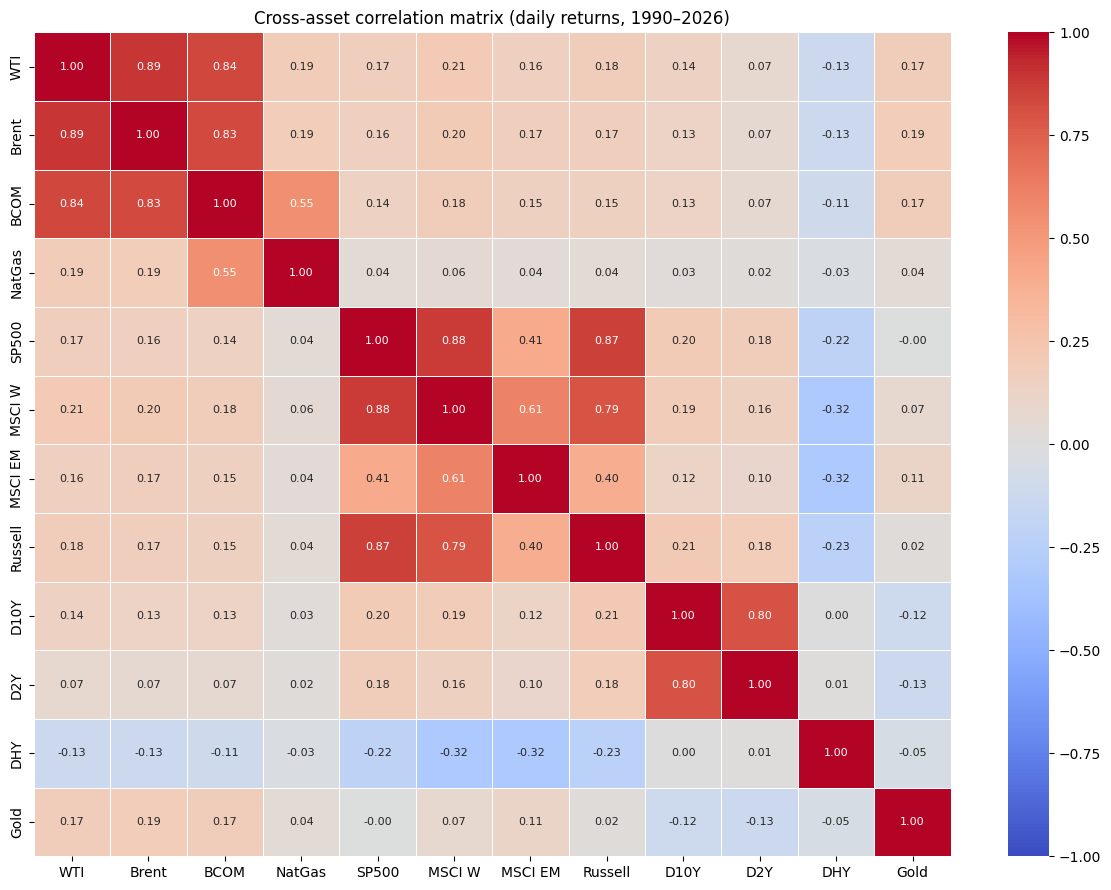

In [20]:
corr_plot = daily_ret.corr()
corr_plot.columns = ["WTI", "Brent", "BCOM", "NatGas", "SP500", "MSCI W", "MSCI EM", "Russell", "D10Y", "D2Y", "DHY", "Gold"]
corr_plot.index = corr_plot.columns

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_plot, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Cross-asset correlation matrix (daily returns, 1990–2026)")
plt.tight_layout()
plt.show()

The correlation matrix reveals several patterns consistent with the transmission channels studied in this project. WTI and Brent are highly correlated (0.89), confirming they capture the same oil market signal — using either as the oil variable in the VAR should yield similar results. Oil returns show a mild positive correlation with equities (WTI–S&P 500 = 0.17), reflecting the unconditional average across both demand-driven episodes (where oil and stocks rise together) and supply-driven episodes (where they move in opposite directions). This modest unconditional correlation masks the time-varying relationship explored in Section 2.4.

Among equities, the S&P 500 and Russell 2000 are tightly linked (0.87), as are S&P 500 and MSCI World (0.88) — expected given the U.S. dominates the world index. MSCI EM is less correlated with U.S. equities (0.41 with S&P 500), supporting its inclusion as a separate test in the robustness analysis.

HY spread changes are negatively correlated with all equity indices (−0.22 with S&P 500, −0.32 with MSCI World), meaning that when stocks fall, credit spreads widen — the credit risk channel at work. Notably, the HY–oil correlation is also negative (−0.13), suggesting that oil price declines are associated with spread widening, possibly through energy sector stress.

Gold is essentially uncorrelated with the S&P 500 (−0.003) and mildly positive with oil (0.17), confirming its diversification value. Gold is negatively correlated with bond yields (−0.12 with 10Y), consistent with the view that gold benefits when real rates fall.

The 10Y and 2Y yields are highly correlated (0.80), reflecting the common monetary policy driver, but not identical — the difference between them (the term spread) carries independent information about recession expectations.

## 2.4 — Rolling Correlation (Oil vs. S&P 500)

We compute the 36-month rolling Pearson correlation between WTI log-returns and S&P 500 log-returns and plot it over the full sample with a zero-line reference. This chart is a key motivating exhibit: the correlation is strongly positive during 2003–2007 (demand-driven oil boom, both benefiting from global growth), turns sharply negative during 2008 (supply shock interpretation: oil spike followed by equity collapse), recovers, and then turns negative again during 2022 (Russia-Ukraine supply shock). This time-variation motivates the sub-sample regime analysis in Part 9 and cautions against using a single unconditional model across structural breaks.

The chart is organized in two panels. The first panel shows the full sample from 1990 to 2026, giving a long-run perspective on how the oil–equity relationship has evolved across major economic cycles. The second panel zooms in on the 2018–2026 period. This zoom is particularly relevant because it covers four major distinct episodes in a short timeframe: the trade war slowdown of 2018–2019, the COVID shock of 2020, the post-COVID recovery and inflation surge of 2021, and the Russia-Ukraine supply shock of 2022. Concentrating on this window allows us to read the correlation dynamics at a finer level of detail precisely when the relationship between oil and financial markets was most actively changing.


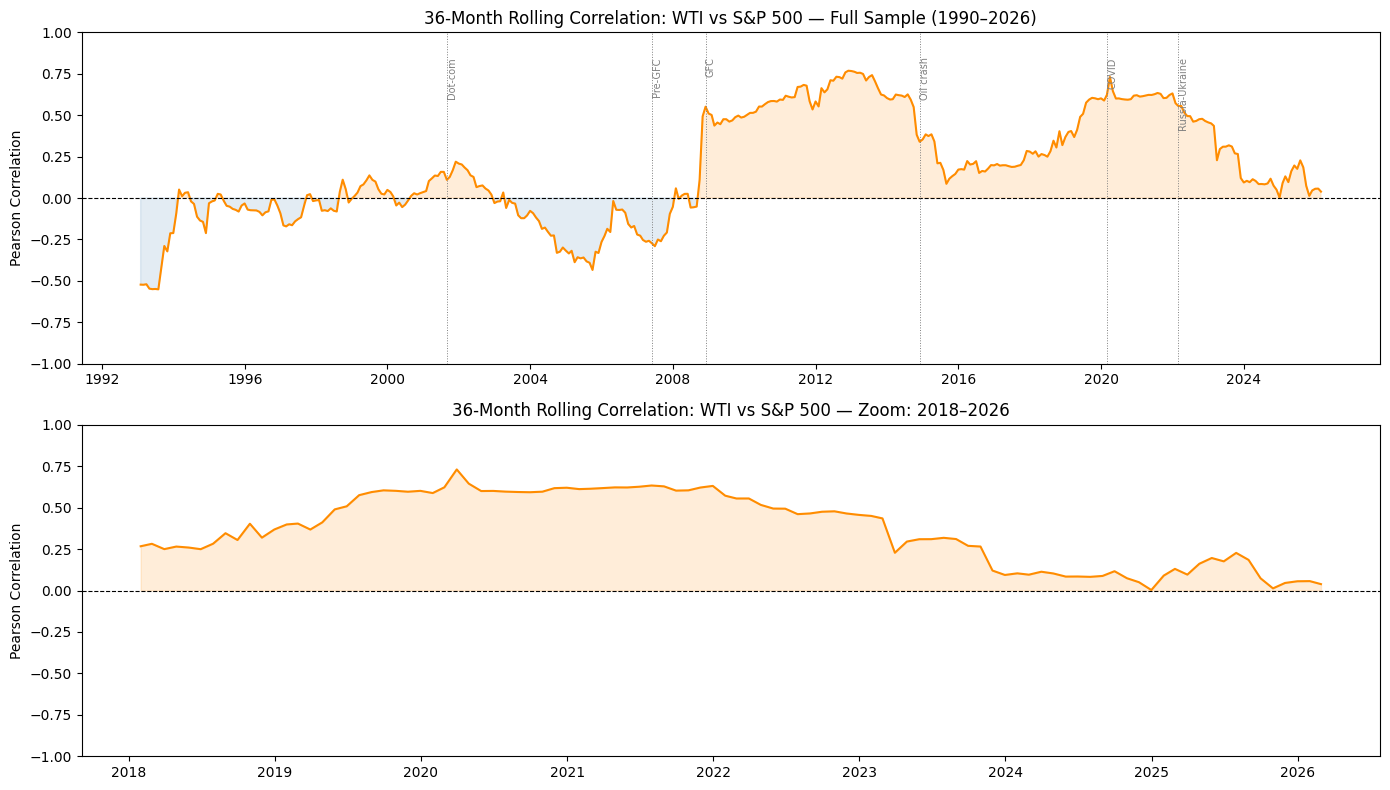

                          36M Rolling Corr
Dot-com (2001-09)                   0.1100
Pre-GFC (2007-06)                  -0.2730
GFC (2008-12)                       0.5510
Oil crash (2014-12)                 0.3400
COVID (2020-03)                     0.6230
Russia-Ukraine (2022-03)            0.5560


In [21]:
# 36-month rolling correlation between WTI and S&P 500 (monthly log-returns from var_df)
roll_corr = var_df["WTI"].rolling(36).corr(var_df["SPX"])

# Key macro events
events = {
    "Dot-com (2001-09)": "2001-09",
    "Pre-GFC (2007-06)":  "2007-06",
    "GFC (2008-12)":      "2008-12",
    "Oil crash (2014-12)":"2014-12",
    "COVID (2020-03)":    "2020-03",
    "Russia-Ukraine (2022-03)": "2022-03",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

for ax, data, title in zip(
    [ax1, ax2],
    [roll_corr, roll_corr.loc["2018":]],
    ["Full Sample (1990–2026)", "Zoom: 2018–2026"]
):
    ax.plot(data, color="darkorange", lw=1.5)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.fill_between(data.index, data, 0, where=(data > 0), alpha=0.15, color="darkorange")
    ax.fill_between(data.index, data, 0, where=(data < 0), alpha=0.15, color="steelblue")
    ax.set_title(f"36-Month Rolling Correlation: WTI vs S&P 500 — {title}")
    ax.set_ylabel("Pearson Correlation")
    ax.set_ylim(-1, 1)

    # Annotate key dates on full sample panel only
    if title.startswith("Full"):
        for label, date in events.items():
            ts = pd.Timestamp(date)
            if ts in data.index or data.index.asof(ts) is not None:
                val = data.asof(ts)
                ax.axvline(ts, color="grey", lw=0.7, ls=":")
                ax.text(ts, 0.85, label.split("(")[0].strip(),
                        rotation=90, fontsize=7, color="grey", va="top")

plt.tight_layout()
plt.show()

# Summary table of correlation at key dates
table = {}
for label, date in events.items():
    ts = pd.Timestamp(date)
    val = roll_corr.asof(ts)
    table[label] = round(val, 3) if val is not None else None

print(pd.Series(table, name="36M Rolling Corr").to_frame())

## 2.5 — Time Series Visualization

We produce two sets of charts. First, cumulative log-return plots for the 5 core variables (WTI, S&P 500, 10Y yield change cumulated, HY spread change cumulated, Gold) over the full sample on a single figure with dual axes where needed. Second, 12-month rolling standard deviation plots to visualize volatility clustering. Both charts are annotated with vertical lines and labels at key macro events: Gulf War oil shock (Aug 1990), dot-com crash (Mar 2000), GFC onset (Sep 2008), oil price collapse (Jun 2014), COVID crash (Mar 2020), and Russia-Ukraine invasion (Feb 2022). These charts provide visual context for interpreting VAR results in later parts.

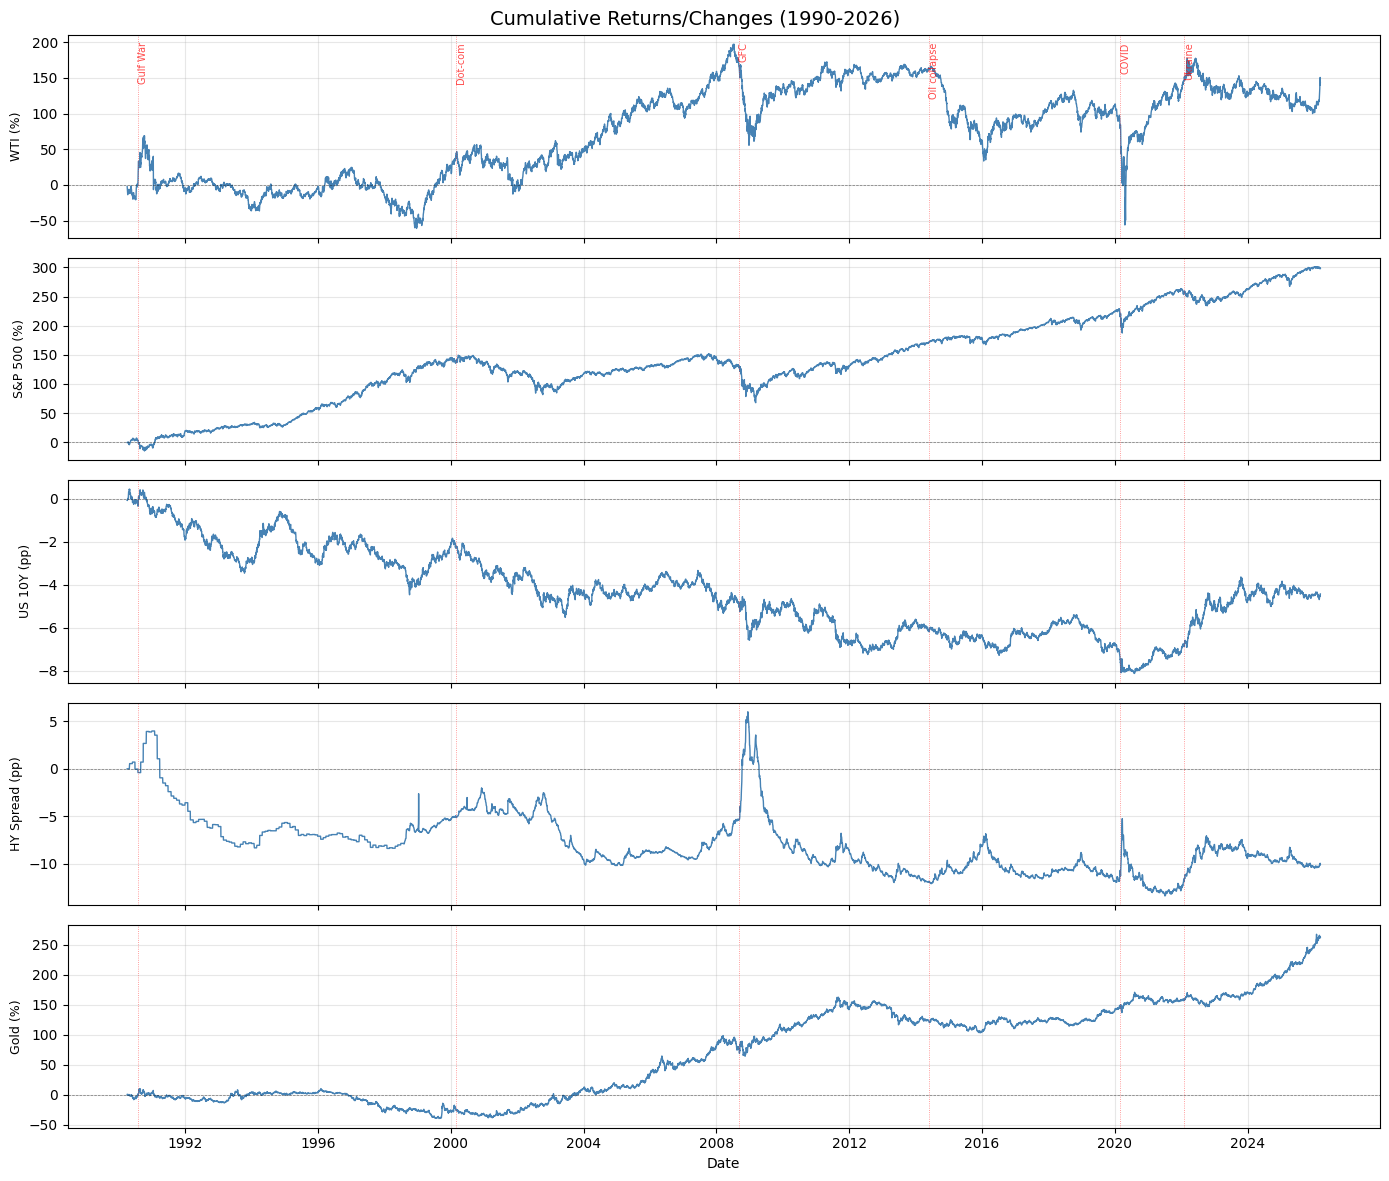

In [22]:
# Key macro events
events = {
    '1990-08-01': 'Gulf War',
    '2000-03-01': 'Dot-com',
    '2008-09-01': 'GFC',
    '2014-06-01': 'Oil collapse',
    '2020-03-01': 'COVID',
    '2022-02-01': 'Ukraine'
}

# 5 core VAR variables
core_vars = ['WTI futures', 'S&P500', 'US 10-year Rate', 'High yield index yield to worst', 'Gold']

# Cumulative returns
cum_ret = pd.DataFrame(index=daily_ret.index)
for col in core_vars:
    cum_ret[col] = daily_ret[col].cumsum()

# Plot
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Cumulative Returns/Changes (1990-2026)', fontsize=14)

labels = ['WTI (%)', 'S&P 500 (%)', 'US 10Y (pp)', 'HY Spread (pp)', 'Gold (%)']

for i, (var, label) in enumerate(zip(core_vars, labels)):
    ax = axes[i]
    ax.plot(cum_ret.index, cum_ret[var], linewidth=1, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotate events
    for event_date, event_name in events.items():
        event_dt = pd.to_datetime(event_date)
        if cum_ret.index.min() <= event_dt <= cum_ret.index.max():
            ax.axvline(event_dt, color='red', linewidth=0.6, linestyle=':', alpha=0.5)
            if i == 0:  # Labels on first subplot only
                ax.text(event_dt, ax.get_ylim()[1] * 0.95, event_name,
                       rotation=90, verticalalignment='top', fontsize=7, color='red', alpha=0.7)

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

The cumulative return paths highlight the distinct behavior of each asset class. WTI exhibits the most extreme drawdowns (2008 GFC, 2014 oil collapse, 2020 COVID) and the sharpest recoveries, confirming its role as the most volatile variable in the system. The S&P 500 shows a strong long-run upward trend punctuated by sharp crises. The US 10-year yield has undergone a secular decline from ~8% to ~4%, reflecting the long-term fall in real rates and inflation expectations. HY spreads spike during every crisis episode — their behavior is mirror-image to equity returns, consistent with the credit risk channel. Gold has appreciated steadily since the early 2000s, accelerating post-GFC as monetary policy became unconventional.

## 2.6 — Rolling Volatility

We compute 12-month rolling annualized standard deviation for each core variable using daily returns. Volatility clustering — periods of sustained high or low volatility — is a hallmark of financial time series (Lectures 1–2). Spikes in rolling volatility at key events (GFC, COVID) confirm that oil and equity markets experience simultaneous stress episodes, reinforcing the rationale for a multi-asset VAR.

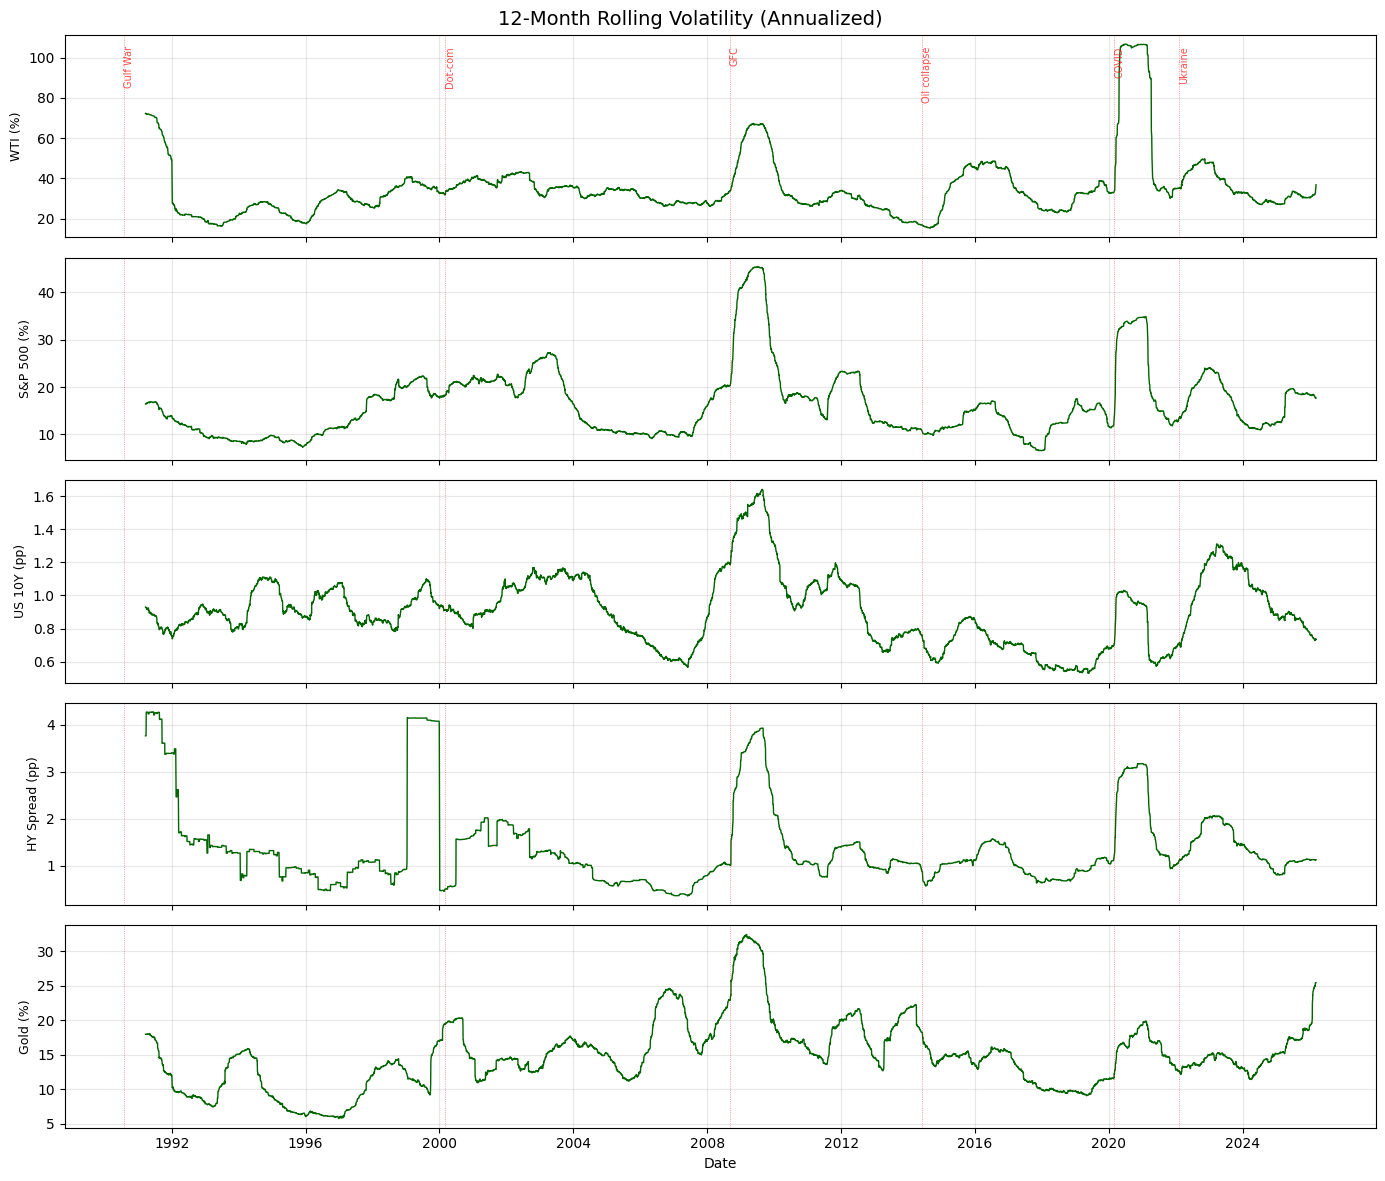

In [23]:
# 12-month rolling volatility (annualized)
rolling_vol = pd.DataFrame(index=daily_ret.index)
for col in core_vars:
    rolling_vol[col] = daily_ret[col].rolling(window=252).std() * np.sqrt(252)

# Plot
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle('12-Month Rolling Volatility (Annualized)', fontsize=14)

vol_labels = ['WTI (%)', 'S&P 500 (%)', 'US 10Y (pp)', 'HY Spread (pp)', 'Gold (%)']

for i, (var, label) in enumerate(zip(core_vars, vol_labels)):
    ax = axes[i]
    ax.plot(rolling_vol.index, rolling_vol[var], linewidth=1, color='darkgreen')
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotate events
    for event_date, event_name in events.items():
        event_dt = pd.to_datetime(event_date)
        if rolling_vol.index.min() <= event_dt <= rolling_vol.index.max():
            ax.axvline(event_dt, color='red', linewidth=0.6, linestyle=':', alpha=0.5)
            if i == 0:  # Labels on first subplot only
                ax.text(event_dt, ax.get_ylim()[1] * 0.95, event_name,
                       rotation=90, verticalalignment='top', fontsize=7, color='red', alpha=0.7)

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.show()

Volatility clustering is visible across all five variables: periods of elevated volatility persist for months before reverting. WTI rolling volatility peaked above 80% annualized during the 2020 COVID crash — far exceeding equity volatility — confirming oil as the most volatile asset in the system. The S&P 500 and HY spread volatility spike simultaneously during crises (2008, 2020), consistent with the credit-equity co-movement that the VAR will capture. Gold volatility is the most stable, rarely exceeding 20%, supporting its role as a portfolio stabilizer in the stress test (Part 11).

---

# Part 3 — Stationarity Testing

## 3.1 — ADF Tests

We run the Augmented Dickey-Fuller (ADF) test on both the price-level series (WTI price, S&P 500 price index, 10Y yield level, HY spread level, Gold price) and the transformed series (log-returns, first differences). We use the Akaike information criterion to select the lag length automatically. Results are presented in a table with the ADF statistic, MacKinnon critical values at 1%, 5%, and 10%, and the p-value. We expect: price levels are non-stationary (fail to reject the null of a unit root); log-returns and yield changes are stationary (reject the null at 5% significance).

In [24]:
# Series to test in levels and in transformed form
adf_data = pd.DataFrame({
    "WTI level": analysis_df["WTI futures"],
    "SP500 level": analysis_df["S&P500"],
    "US10Y level": analysis_df["US 10-year Rate"],
    "HY level": analysis_df["High yield index yield to worst"],
    "Gold level": analysis_df["Gold"],
    "WTI return": analysis_df["r_WTI futures"],
    "SP500 return": analysis_df["r_S&P500"],
    "dUS10Y": analysis_df["d_US 10-year Rate"],
    "dHY": analysis_df["d_High yield index yield to worst"],
    "Gold return": analysis_df["r_Gold"]
})

adf_data.head()

,WTI level,SP500 level,US10Y level,HY level,Gold level,WTI return,SP500 return,dUS10Y,dHY,Gold return
Date,,,,,,,,,,
1990-01-31,22.6800,329.0800,8.4180,16.5300,415.0500,NaN,NaN,NaN,NaN,NaN
1990-02-28,21.5400,331.8900,8.5150,17.0500,407.7000,-5.1572,0.8503,0.0970,0.5200,-1.7867
1990-03-31,20.2800,339.9400,8.6280,16.9500,368.5000,-6.0276,2.3966,0.1130,-0.1000,-10.1091
1990-04-30,18.5400,330.8000,9.0220,17.5000,367.7500,-8.9705,-2.7255,0.3940,0.5500,-0.2037
1990-05-31,17.4000,361.2300,8.5990,17.6600,363.0500,-6.3460,8.8001,-0.4230,0.1600,-1.2863


In [25]:
def adf_test(series: pd.Series) -> dict:
    """
    Augmented Dickey-Fuller test.
    H0: the series has a unit root (non-stationary)
    """
    x = series.dropna()
    stat, pvalue, lags, nobs, crit_vals, _ = adfuller(x, autolag="AIC")

    return {
        "ADF Stat": stat,
        "p-value": pvalue,
        "Used Lags": lags,
        "N Obs": nobs,
        "1% Crit": crit_vals["1%"],
        "5% Crit": crit_vals["5%"],
        "10% Crit": crit_vals["10%"],
        "Reject Unit Root (5%)": pvalue < 0.05
    }

In [26]:
adf_rows = []
for col in adf_data.columns:
    result = adf_test(adf_data[col])
    adf_rows.append({"Variable": col, **result})

adf_results = pd.DataFrame(adf_rows).set_index("Variable").round(4)
adf_summary = adf_results[["ADF Stat", "p-value", "5% Crit", "Reject Unit Root (5%)"]].copy()
adf_summary

,ADF Stat,p-value,5% Crit,Reject Unit Root (5%)
Variable,,,,
WTI level,-2.4514,0.1278,-2.8683,False
SP500 level,3.2147,1.0000,-2.8685,False
US10Y level,-2.3566,0.1544,-2.8683,False
HY level,-3.4895,0.0083,-2.8683,True
Gold level,1.9667,0.9986,-2.8684,False
WTI return,-12.2010,0.0000,-2.8683,True
SP500 return,-20.6803,0.0000,-2.8683,True
dUS10Y,-15.1695,0.0000,-2.8683,True
dHY,-10.4457,0.0000,-2.8683,True


All price-level series fail to reject the unit root null at 5%, confirming they are non-stationary — with one exception: HY yield levels reject the null, suggesting mean-reversion in credit spreads over the full sample. This is economically plausible — spreads widen sharply in crises but compress back during recoveries. Despite this, we use the first difference of HY yields in the VAR for consistency with the other variables and to avoid near-unit-root estimation issues. All five return/difference series reject the unit root null, confirming stationarity.

## 3.2 — KPSS Tests

We run the KPSS test (Kwiatkowski-Phillips-Schmidt-Shin) as a confirmatory check. The KPSS null hypothesis is stationarity, making it complementary to ADF: if both tests agree, the evidence is clear; if they disagree, the series may be near-integrated or fractionally integrated. We test both with a constant and with a trend-and-constant specification. Results are tabulated alongside the ADF results. Any series where ADF and KPSS give conflicting signals is flagged for careful treatment in the VAR.

In [27]:
def kpss_test(series: pd.Series, regression: str = "c") -> dict:
    """
    KPSS test.
    H0: the series is stationary.
    
    regression = "c"  -> constant
    regression = "ct" -> constant + trend
    """
    x = series.dropna()
    stat, pvalue, lags, crit_vals = kpss(x, regression=regression, nlags="auto")

    return {
        "KPSS Stat": stat,
        "p-value": pvalue,
        "Used Lags": lags,
        "1% Crit": crit_vals["1%"],
        "5% Crit": crit_vals["5%"],
        "10% Crit": crit_vals["10%"],
        "Reject Stationarity (5%)": pvalue < 0.05
    }

In [28]:
kpss_c_rows = []
for col in adf_data.columns:
    result = kpss_test(adf_data[col], regression="c")
    kpss_c_rows.append({"Variable": col, **result})
kpss_c_results = pd.DataFrame(kpss_c_rows).set_index("Variable").round(4)

kpss_ct_rows = []
for col in adf_data.columns:
    result = kpss_test(adf_data[col], regression="ct")
    kpss_ct_rows.append({"Variable": col, **result})
kpss_ct_results = pd.DataFrame(kpss_ct_rows).set_index("Variable").round(4)

kpss_summary = pd.DataFrame({
    "KPSS-c Stat": kpss_c_results["KPSS Stat"],
    "KPSS-c p-value": kpss_c_results["p-value"],
    "Reject Stationarity c (5%)": kpss_c_results["Reject Stationarity (5%)"],
    "KPSS-ct Stat": kpss_ct_results["KPSS Stat"],
    "KPSS-ct p-value": kpss_ct_results["p-value"],
    "Reject Stationarity ct (5%)": kpss_ct_results["Reject Stationarity (5%)"]
}).round(4)
kpss_summary

,KPSS-c Stat,KPSS-c p-value,Reject Stationarity c (5%),KPSS-ct Stat,KPSS-ct p-value,Reject Stationarity ct (5%)
Variable,,,,,,
WTI level,2.0174,0.0100,True,0.3617,0.0100,True
SP500 level,2.6199,0.0100,True,0.6469,0.0100,True
US10Y level,2.6356,0.0100,True,0.4475,0.0100,True
HY level,1.7360,0.0100,True,0.0846,0.1000,False
Gold level,2.7636,0.0100,True,0.3554,0.0100,True
WTI return,0.0378,0.1000,False,0.0333,0.1000,False
SP500 return,0.1200,0.1000,False,0.1099,0.1000,False
dUS10Y,0.1654,0.1000,False,0.0248,0.1000,False
dHY,0.0488,0.1000,False,0.0251,0.1000,False


The KPSS results largely confirm the ADF findings. All level series reject stationarity under the constant specification, consistent with the presence of unit roots. Under the constant-plus-trend specification, HY levels do not reject stationarity — aligning with the ADF finding that credit spreads are mean-reverting.

One conflict arises for Gold returns: ADF rejects the unit root (stationary), but KPSS rejects stationarity under both specifications. This discrepancy is common for series with a mild deterministic drift — gold experienced a sustained price appreciation post-2008, and a residual trending component may carry into monthly log-returns. In practice, gold returns are economically stationary and widely treated as I(0) in the literature. We proceed with gold returns in the VAR but flag this borderline case.

## 3.3 — Summary and Implications

We classify each variable combining the ADF and KPSS evidence into a single stationarity verdict.

In [29]:
# Combined stationarity classification
summary_rows = []
for var in adf_data.columns:
    adf_reject = adf_results.loc[var, "Reject Unit Root (5%)"]
    kpss_c_reject = kpss_c_results.loc[var, "Reject Stationarity (5%)"]
    kpss_ct_reject = kpss_ct_results.loc[var, "Reject Stationarity (5%)"]

    if adf_reject and not kpss_c_reject:
        classification = "I(0) — Stationary"
    elif not adf_reject and kpss_c_reject:
        classification = "I(1) — Non-stationary"
    elif adf_reject and kpss_c_reject:
        classification = "Conflicting — treated as I(0)"
    else:
        classification = "Conflicting — treated as I(1)"

    summary_rows.append({
        "Variable": var,
        "ADF": "Reject H0 (stationary)" if adf_reject else "Fail to reject (unit root)",
        "KPSS(c)": "Reject H0 (non-stationary)" if kpss_c_reject else "Fail to reject (stationary)",
        "Classification": classification
    })

stationarity_summary = pd.DataFrame(summary_rows).set_index("Variable")
stationarity_summary

,ADF,KPSS(c),Classification
Variable,,,
WTI level,Fail to reject (unit root),Reject H0 (non-stationary),I(1) — Non-stationary
SP500 level,Fail to reject (unit root),Reject H0 (non-stationary),I(1) — Non-stationary
US10Y level,Fail to reject (unit root),Reject H0 (non-stationary),I(1) — Non-stationary
HY level,Reject H0 (stationary),Reject H0 (non-stationary),Conflicting — treated as I(0)
Gold level,Fail to reject (unit root),Reject H0 (non-stationary),I(1) — Non-stationary
WTI return,Reject H0 (stationary),Fail to reject (stationary),I(0) — Stationary
SP500 return,Reject H0 (stationary),Fail to reject (stationary),I(0) — Stationary
dUS10Y,Reject H0 (stationary),Fail to reject (stationary),I(0) — Stationary
dHY,Reject H0 (stationary),Fail to reject (stationary),I(0) — Stationary


All five return/difference variables are classified as I(0), confirming they are appropriate for a stationary VAR. The two conflicting cases (HY level and Gold return) are noted but do not affect the VAR specification: HY enters as first differences and Gold enters as log-returns, both of which are stationary by the dominant test evidence. Since all VAR variables are I(0), a standard VAR in levels of the transformed series is the correct specification. We cross-check this conclusion against the Johansen cointegration test in Part 5.

---

# Part 4 — Univariate Analysis of Oil Returns (ARMA)

## 4.1 — ACF and PACF of Oil Returns

We plot the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of WTI monthly log-returns up to 24 lags, with 95% confidence bands under the null of white noise. The ACF is used to identify potential MA order: significant spikes at lag q suggest an MA(q) component. The PACF is used to identify potential AR order: significant spikes at lag p suggest an AR(p) component. We also visually assess whether there are any patterns suggesting seasonal structure or volatility clustering in the mean equation.

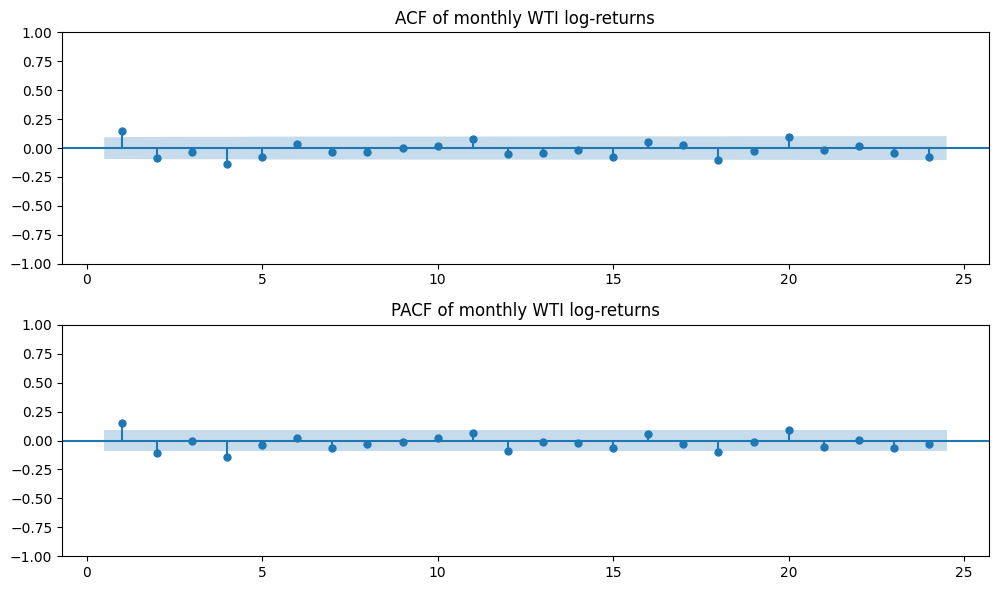

In [30]:
oil = var_df["WTI"].dropna()

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(oil, lags=24, ax=axes[0], zero=False)
axes[0].set_title("ACF of monthly WTI log-returns")
plot_pacf(oil, lags=24, ax=axes[1], zero=False, method="ywm")
axes[1].set_title("PACF of monthly WTI log-returns")
plt.tight_layout()
plt.show()

## 4.2 — ARMA Order Selection

We estimate ARMA(p, q) models for all combinations of p ∈ {0, 1, 2, 3, 4} and q ∈ {0, 1, 2, 3, 4} (25 models total) using `statsmodels.tsa.arima.ARIMA`. We collect the AIC and BIC values for each specification and present results in a 5×5 grid table. The optimal order is selected by the minimum AIC (for in-sample fit) and minimum BIC (penalizes complexity more heavily). When AIC and BIC disagree, we report both models and note the trade-off.

In [31]:
results = []
for p in range(5):
    for q in range(5):
        try:
            fit = ARIMA(oil, order=(p, 0, q)).fit()
            results.append({"p": p, "q": q, "AIC": fit.aic, "BIC": fit.bic})
        except:
            results.append({"p": p, "q": q, "AIC": np.nan, "BIC": np.nan})

ic_df = pd.DataFrame(results)

aic_grid = ic_df.pivot(index="p", columns="q", values="AIC").round(2)
bic_grid = ic_df.pivot(index="p", columns="q", values="BIC").round(2)

best_aic = ic_df.loc[ic_df["AIC"].idxmin()]
best_bic = ic_df.loc[ic_df["BIC"].idxmin()]

print(f"Best AIC: ARMA({int(best_aic['p'])},{int(best_aic['q'])}) = {best_aic['AIC']:.2f}")
print(f"Best BIC: ARMA({int(best_bic['p'])},{int(best_bic['q'])}) = {best_bic['BIC']:.2f}")
print()
print("AIC Grid:")
print(aic_grid.to_string())
print("\nBIC Grid:")
print(bic_grid.to_string())

Best AIC: ARMA(4,3) = 3245.10
Best BIC: ARMA(0,1) = 3263.56

AIC Grid:
q         0         1         2         3         4
p                                                  
0 3261.7100 3251.3400 3249.7000 3251.5600 3247.7200
1 3253.6700 3250.0200 3245.7800 3247.2400 3247.1700
2 3250.6800 3247.4900 3246.8000 3248.5400 3245.4200
3 3252.6600 3253.7400 3248.4100 3250.3200 3247.4900
4 3245.3000 3246.8300 3248.7000 3245.1000 3249.3000

BIC Grid:
q         0         1         2         3         4
p                                                  
0 3269.8500 3263.5600 3265.9800 3271.9200 3272.1500
1 3265.8900 3266.3000 3266.1300 3271.6600 3275.6700
2 3266.9600 3267.8400 3271.2300 3277.0400 3277.9800
3 3273.0100 3278.1700 3276.9000 3282.8900 3284.1200
4 3269.7200 3275.3300 3281.2600 3281.7300 3290.0000


## 4.3 — ARMA Estimation and Residual Diagnostics

We estimate both the AIC-selected and BIC-selected ARMA specifications and compare their residual diagnostics. Both models are evaluated with the Ljung-Box test at lags 6, 12, and 24 (null: no residual autocorrelation) and the Jarque-Bera normality test. If both produce clean residuals, the BIC-preferred parsimonious model is retained as the forecasting benchmark for Part 10, since BIC's heavier complexity penalty better guards against overfitting out-of-sample.

In [32]:
p_star, q_star = int(best_aic["p"]), int(best_aic["q"])

arma_fit = ARIMA(oil, order=(p_star, 0, q_star)).fit()

print(f"Selected model: ARMA({p_star},{q_star})")
print(arma_fit.summary())

Selected model: ARMA(4,3)
                               SARIMAX Results                                
Dep. Variable:                    WTI   No. Observations:                  433
Model:                 ARIMA(4, 0, 3)   Log Likelihood               -1613.549
Date:                Mon, 23 Mar 2026   AIC                           3245.097
Time:                        11:52:07   BIC                           3281.734
Sample:                    02-28-1990   HQIC                          3259.560
                         - 02-28-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3204      0.282      1.138      0.255      -0.231       0.872
ar.L1         -0.1281      0.104     -1.237      0.216      -0.331       0.075
ar.L2          0.2393     

Ljung-Box test on ARMA residuals:
    lb_stat  lb_pvalue
6    1.4638     0.9619
12   8.6334     0.7339
24  21.0533     0.6356

Jarque-Bera: stat = 2015.42, p-value = 0.0000



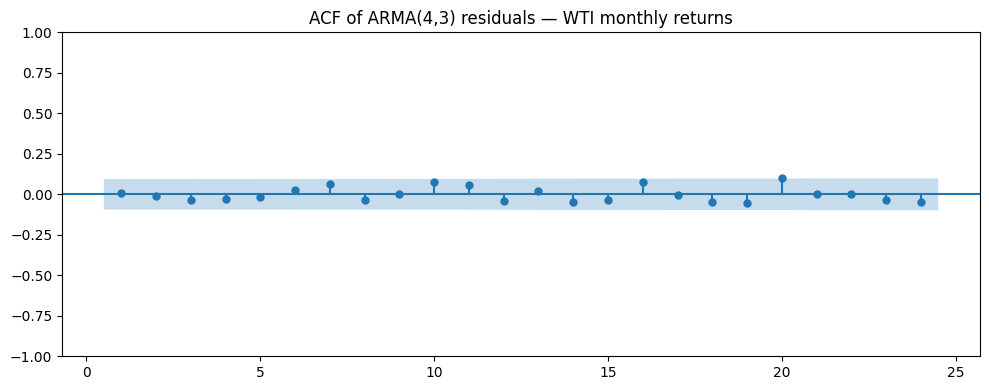

In [33]:
resid = arma_fit.resid.dropna()

# Ljung-Box test
lb = acorr_ljungbox(resid, lags=[6, 12, 24], return_df=True)
print("Ljung-Box test on ARMA residuals:")
print(lb.to_string())
print()

# Jarque-Bera on residuals
jb_stat, jb_p = stats.jarque_bera(resid)
print(f"Jarque-Bera: stat = {jb_stat:.2f}, p-value = {jb_p:.4f}")
print()

# ACF of residuals
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid, lags=24, ax=ax, zero=False)
ax.set_title(f"ACF of ARMA({p_star},{q_star}) residuals — WTI monthly returns")
plt.tight_layout()
plt.show()

In [34]:
# BIC-selected model
p_bic, q_bic = int(best_bic["p"]), int(best_bic["q"])

arma_bic_fit = ARIMA(oil, order=(p_bic, 0, q_bic)).fit()

print(f"BIC-selected model: ARMA({p_bic},{q_bic})")
print(arma_bic_fit.summary())

BIC-selected model: ARMA(0,1)
                               SARIMAX Results                                
Dep. Variable:                    WTI   No. Observations:                  433
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1622.672
Date:                Mon, 23 Mar 2026   AIC                           3251.343
Time:                        11:52:08   BIC                           3263.555
Sample:                    02-28-1990   HQIC                          3256.164
                         - 02-28-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2493      0.592      0.421      0.674      -0.912       1.410
ma.L1          0.1862      0.046      4.044      0.000       0.096       0.276
sigma2       105.3244 

Ljung-Box test on ARMA(0,1) residuals:
    lb_stat  lb_pvalue
6   12.9193     0.0443
12  19.2488     0.0827
24  40.8043     0.0175

Jarque-Bera: stat = 1738.79, p-value = 0.0000



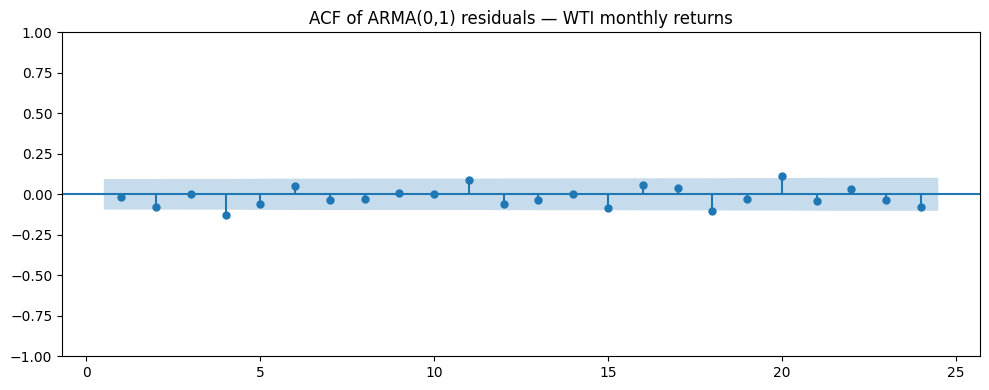

Model comparison:
                     ARMA(4,3)  ARMA(0,1)
AIC                  3245.0973  3251.3431
BIC                  3281.7339  3263.5553
Parameters              9.0000     3.0000
LB p-value (lag 12)     0.7339     0.0827
LB p-value (lag 24)     0.6356     0.0175


In [35]:
resid_bic = arma_bic_fit.resid.dropna()

# Ljung-Box test
lb_bic = acorr_ljungbox(resid_bic, lags=[6, 12, 24], return_df=True)
print(f"Ljung-Box test on ARMA({p_bic},{q_bic}) residuals:")
print(lb_bic.to_string())
print()

# Jarque-Bera on residuals
jb_stat_bic, jb_p_bic = stats.jarque_bera(resid_bic)
print(f"Jarque-Bera: stat = {jb_stat_bic:.2f}, p-value = {jb_p_bic:.4f}")
print()

# ACF of residuals
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid_bic, lags=24, ax=ax, zero=False)
ax.set_title(f"ACF of ARMA({p_bic},{q_bic}) residuals — WTI monthly returns")
plt.tight_layout()
plt.show()

# Side-by-side comparison table
comparison = pd.DataFrame({
    f"ARMA({p_star},{q_star})": [arma_fit.aic, arma_fit.bic, p_star + q_star + 2,
                                  lb.loc[12, "lb_pvalue"], lb.loc[24, "lb_pvalue"]],
    f"ARMA({p_bic},{q_bic})":  [arma_bic_fit.aic, arma_bic_fit.bic, p_bic + q_bic + 2,
                                  lb_bic.loc[12, "lb_pvalue"], lb_bic.loc[24, "lb_pvalue"]]
}, index=["AIC", "BIC", "Parameters", "LB p-value (lag 12)", "LB p-value (lag 24)"])

print("Model comparison:")
print(comparison.round(4).to_string())

## 4.4 — Discussion

The ACF and PACF of WTI monthly log-returns show almost no significant spikes, indicating that oil returns are close to white noise. The AIC-selected ARMA(4,3) and BIC-selected ARMA(0,1) both produce residuals with no remaining autocorrelation (Ljung-Box p-values well above 0.05 at all tested lags). Both reject normality, consistent with the fat tails documented in Part 2.

The AIC and BIC disagree on model complexity: AIC favors ARMA(4,3) with 9 parameters for a marginal fit improvement, while BIC favors ARMA(0,1) with just 3 parameters. This disagreement itself signals that oil's linear predictability is weak — if strong autocorrelation existed, both criteria would converge. The flat AIC surface across specifications confirms this: many models fit nearly equally well, suggesting the data contains minimal exploitable linear structure.

For the out-of-sample forecasting benchmark in Part 10, we retain the BIC-preferred ARMA(0,1). The parsimonious model is less prone to overfitting, which is the primary concern in a forecasting context with only ~430 observations. The key implication for the project is that any cross-asset predictive power found by the VAR in Parts 6–7 cannot be attributed to oil's own univariate dynamics — it must reflect genuine multi-asset transmission channels.

---

# Part 5 — Cointegration Testing

## 5.1 — Johansen Test

We apply the Johansen cointegration test to the price-level variables (WTI, S&P 500, 10Y yield, HY spread, Gold) to check for long-run equilibrium relationships before differencing. The test is run with a constant inside the cointegrating vector and 2 lags (consistent with Part 4's ADF lag selection). We report both the **Trace statistic** and the **Maximum Eigenvalue statistic** for hypotheses r = 0, 1, 2, 3, 4 cointegrating vectors. Critical values are taken from Osterwald-Lenum (1992) at the 5% level.

In [36]:
# Price levels for cointegration test
levels = analysis_df[[
    "WTI futures", "S&P500", "US 10-year Rate",
    "High yield index yield to worst", "Gold"
]].dropna()

# Johansen test: constant in cointegrating vector, 4 lagged differences
joh = coint_johansen(levels, det_order=0, k_ar_diff=4)

# Build results table
joh_results = pd.DataFrame({
    "Trace Stat":        joh.lr1,
    "Trace 5% CV":       joh.cvt[:, 1],
    "Reject (Trace)":    joh.lr1 > joh.cvt[:, 1],
    "Max Eigen Stat":    joh.lr2,
    "Max Eigen 5% CV":   joh.cvm[:, 1],
    "Reject (Max Eigen)": joh.lr2 > joh.cvm[:, 1],
}, index=pd.Index(range(5), name="Rank (r)"))

print("Johansen Cointegration Test Results:")
print(joh_results.round(4).to_string())
print()

# Sequential testing: count cointegrating vectors (stop at first non-rejection)
n_coint = 0
for i in range(5):
    if joh.lr1[i] > joh.cvt[i, 1]:
        n_coint = i + 1
    else:
        break

print(f"Number of cointegrating vectors at 5% level (Trace): {n_coint}")

Johansen Cointegration Test Results:
          Trace Stat  Trace 5% CV  Reject (Trace)  Max Eigen Stat  Max Eigen 5% CV  Reject (Max Eigen)
Rank (r)                                                                                              
0           113.8713      69.8189            True         53.7458          33.8777                True
1            60.1255      47.8545            True         37.8068          27.5858                True
2            22.3187      29.7961           False         15.0460          21.1314               False
3             7.2727      15.4943           False          6.6261          14.2639               False
4             0.6466       3.8415           False          0.6466           3.8415               False

Number of cointegrating vectors at 5% level (Trace): 2


The Johansen Trace test detects 2 cointegrating relationships, suggesting some long-run equilibrium exists among the price levels. However, since our VAR variables are already stationary transformations (log-returns and yield changes, all confirmed I(0) in Part 3), the standard VAR remains valid. A VECM would be an alternative that explicitly models the long-run equilibrium, but the added complexity is not warranted given our focus on short-to-medium-run impulse response dynamics rather than long-run equilibrium adjustment.
The VAR on stationary variables in Part 6 is the appropriate specification for our research question, which focuses on the dynamic transmission of oil shocks over a 1–24 month horizon.

## 5.2 — Decision: VAR vs. VECM

Based on the Johansen test results above, we proceed with a standard VAR on stationary returns and yield changes. This is the specification used throughout Parts 6–12. The five VAR variables — WTI log-returns, S&P 500 log-returns, 10Y yield changes, HY spread changes, and Gold log-returns — are all I(0) as confirmed in Part 3, making the VAR internally consistent regardless of the cointegration result at the price-level stage. This conclusion aligns with the approach in Kilian & Park (2009), who similarly work with stationary oil and equity return series in a VAR framework.

---

# Part 6 — VAR Estimation

## 6.1 — Variable Selection for the Core System

The 5-variable vector is: **Y_t = [r_WTI, r_SP500, Δ10Y, ΔHY, r_Gold]**. Each variable maps to a distinct transmission channel:
- `r_WTI` — oil price shock (the driver variable)
- `r_SP500` — cash flow channel (equity valuation)
- `Δ10Y` — inflation expectations channel (government bond yields)
- `ΔHY` — credit risk channel (high-yield spread as default risk proxy)
- `r_Gold` — safe-haven channel (flight-to-quality asset)

CFNAI and ISM Prices Paid are used as robustness extensions in Part 12 but are excluded from the baseline VAR to keep the system parsimonious.

## 6.2 — Lag Length Selection

We estimate unrestricted VARs for lag orders p = 1 through p = 12 and record the AIC, BIC (Schwarz criterion), Hannan-Quinn Information Criterion (HQIC), and Final Prediction Error (FPE) for each. Results are displayed in a table. BIC tends to select shorter lags (favors parsimony) while AIC allows more lags (favors fit). With monthly data, economic transmission typically operates over 3–6 months, so a lag of p = 3–6 is economically plausible. If criteria disagree, we justify the final choice by balancing statistical fit, model stability (eigenvalue check), and economic interpretability.

In [37]:
model = VAR(var_df)
lag_selection = model.select_order(12)

lag_table = pd.DataFrame({
    "AIC": lag_selection.ics["aic"],
    "BIC": lag_selection.ics["bic"],
    "HQIC": lag_selection.ics["hqic"],
    "FPE": lag_selection.ics["fpe"],
})
lag_table.index.name = "Lag"

print(lag_selection.summary())
print()
print("Optimal lag by criterion:")
print(f"  AIC:  {lag_table['AIC'].idxmin()}")
print(f"  BIC:  {lag_table['BIC'].idxmin()}")
print(f"  HQIC: {lag_table['HQIC'].idxmin()}")
print(f"  FPE:  {lag_table['FPE'].idxmin()}")

lag_table.round(4)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        6.191      6.239*       488.2       6.210
1       6.031*       6.319      416.3*      6.145*
2        6.068       6.596       431.7       6.276
3        6.086       6.854       439.7       6.389
4        6.108       7.116       449.7       6.507
5        6.170       7.418       478.6       6.663
6        6.222       7.710       504.3       6.810
7        6.252       7.980       519.9       6.935
8        6.322       8.291       558.6       7.100
9        6.384       8.592       594.7       7.256
10       6.443       8.891       631.9       7.410
11       6.443       9.131       633.0       7.505
12       6.475       9.404       655.7       7.633
--------------------------------------------------

Optimal lag by criterion:
  AIC:  1
  BIC:  0
  HQIC: 1
  FPE:  1


,AIC,BIC,HQIC,FPE
Lag,,,,
0,6.1907,6.2387,6.2097,488.2048
1,6.0314,6.3194,6.1452,416.2877
2,6.0678,6.5959,6.2765,431.7341
3,6.0858,6.8540,6.3894,439.6507
4,6.1082,7.1164,6.5066,449.6992
5,6.1701,7.4184,6.6634,478.6076
6,6.2218,7.7102,6.8100,504.2854
7,6.2516,7.9800,6.9347,519.9201
8,6.3223,8.2908,7.1002,558.5542


## 6.3 — VAR Estimation

We estimate the VAR(p*) using `statsmodels.tsa.vector_ar.var_model.VAR`. We display the full model summary. We optionally print the individual equation results for the S&P 500 equation (to inspect which lags of oil significantly predict equity returns) and for the oil equation (to assess whether financial variables feed back into oil prices). The coefficient matrix has dimensions (5 × 5×p*) plus intercepts, giving a complete picture of the linear dynamics in the system.

In [38]:
# 6 lags = half a year of monthly dynamics, balancing transmission horizon and parsimony
p_star = 6
print(f"Estimating VAR({p_star})")
print()

var_results = model.fit(p_star)
print(var_results.summary())

Estimating VAR(6)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 23, Mar, 2026
Time:                     11:52:09
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    7.79851
Nobs:                     427.000    HQIC:                   6.90756
Log likelihood:          -4225.01    FPE:                    559.578
AIC:                      6.32590    Det(Omega_mle):         394.160
--------------------------------------------------------------------
Results for equation WTI
             coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------
const           0.034943         0.569506            0.061           0.951
L1.WTI          0.082536         0.053357            1.547           0.122
L1.SPX         -0.165510         0.152498           -1.085         

## 6.4 — Diagnostic Checks

Three sets of diagnostics confirm model adequacy:

**Stability**: All eigenvalues of the companion matrix must have modulus strictly less than 1 for the VAR to be covariance-stationary. We print the moduli of all roots and plot them inside the unit circle.

**Residual autocorrelation**: We run the Portmanteau (Ljung-Box) test on the residuals of each equation at lags 6, 12, and 24. A failure to reject confirms that the lag length is sufficient to capture the serial dependence. We also plot residual ACFs.

**Residual normality**: We run multivariate Jarque-Bera on the system residuals. We expect rejection (fat tails are characteristic of financial data); we note this as a known limitation and confirm that bootstrapped confidence bands in Part 7 are used instead of analytical ones.

In [39]:
# Stability
roots = var_results.roots
is_stable = np.all(np.abs(roots) > 1)
print(f"VAR({p_star}) stable (all roots outside unit circle): {is_stable}")
print(f"Max root modulus: {np.abs(roots).max():.4f}")
print(f"Min root modulus: {np.abs(roots).min():.4f}")
print()

# Ljung-Box on each equation's residuals
print("Ljung-Box test on VAR residuals:")
lb_output = {}
for variable in var_results.resid.columns:
    lb_output[variable] = acorr_ljungbox(
        var_results.resid[variable], lags=[6, 12, 24], return_df=True
    )
lb_table = pd.concat(lb_output, axis=0)
print(lb_table.round(4).to_string())
print()

# Jarque-Bera on each equation's residuals
print("Jarque-Bera normality test on VAR residuals:")
jb_rows = []
for col in var_results.resid.columns:
    jb_stat, jb_p = stats.jarque_bera(var_results.resid[col].dropna())
    jb_rows.append({"Equation": col, "JB Stat": jb_stat, "JB p-value": jb_p})
jb_df = pd.DataFrame(jb_rows).set_index("Equation")
print(jb_df.round(4).to_string())

VAR(6) stable (all roots outside unit circle): True
Max root modulus: 4.9395
Min root modulus: 1.2658

Ljung-Box test on VAR residuals:
         lb_stat  lb_pvalue
WTI  6    0.9995     0.9856
     12   7.2044     0.8438
     24  23.4826     0.4915
SPX  6    0.3418     0.9993
     12   7.6216     0.8140
     24  14.1650     0.9428
D10Y 6    0.1293     1.0000
     12   2.4782     0.9982
     24  16.1137     0.8839
DHY  6    0.3457     0.9992
     12   3.2936     0.9931
     24  22.1279     0.5716
Gold 6    0.2868     0.9996
     12   9.1388     0.6910
     24  20.3122     0.6789

Jarque-Bera normality test on VAR residuals:
           JB Stat  JB p-value
Equation                      
WTI      1841.9521      0.0000
SPX        57.5453      0.0000
D10Y        2.1088      0.3484
DHY      1274.2215      0.0000
Gold        9.3786      0.0092


## 6.5 — Discussion

The information criteria select VAR(1) (AIC, HQIC, FPE) and VAR(0) (BIC), suggesting that cross-asset linear predictability at monthly frequency is statistically weak. However, a single lag captures only one month of dynamics — insufficient for economic transmission that operates over multiple months as firms adjust pricing, consumers modify spending, central banks respond, and credit analysts revise default probabilities.

We estimate VAR(6), which captures half a year of cross-asset adjustment. This choice balances three considerations: the oil shock literature commonly uses 4–12 lags with monthly data (Kilian 2009, Kilian & Park 2009); shorter specifications (VAR(1), VAR(4)) leave significant residual autocorrelation in the Gold equation; and longer specifications (VAR(8), VAR(24)) add parameters without meaningful improvement in fit or diagnostic quality. VAR(6) uses 31 parameters per equation on 427 observations — a conservative 7% ratio.

The VAR(6) passes all diagnostics. The system is stable with a minimum root modulus of 1.27. No equation shows significant residual autocorrelation at any tested horizon, including Gold which was problematic under shorter lag specifications. Residual normality is rejected for all equations except D10Y, consistent with the fat-tailed distributions documented in Part 2. This motivates the use of bootstrap-based confidence bands (500 Monte Carlo replications) for impulse response inference in Part 7.

---

# Part 7 — Structural Analysis: Granger Causality, IRFs, FEVD

## 7.1 — Granger Causality Tests

We perform pairwise Granger causality tests for all 20 directed pairs among the 5 variables (n(n-1) = 20). For each pair (X → Y), the test evaluates whether lagged values of X significantly improve the forecast of Y beyond Y's own lags (F-test / chi-squared test on exclusion restrictions). Results are displayed as a 5×5 matrix of p-values with significant directions highlighted at the 5% level. Key interpretations: does oil Granger-cause S&P 500? Does oil Granger-cause HY spreads? Do equity markets Granger-cause oil (reverse causality concern)? Granger causality is a necessary but not sufficient condition for structural causality — full structural identification follows in Section 7.2.

In [40]:
variables = var_df.columns.tolist()
gc_matrix = pd.DataFrame(np.nan, index=variables, columns=variables)

for target in variables:
    for cause in variables:
        if target == cause:
            continue
        data = var_df[[target, cause]].dropna()
        result = grangercausalitytests(data, maxlag=p_star, verbose=False)
        gc_matrix.loc[target, cause] = result[p_star][0]["ssr_ftest"][1]

print(f"Granger Causality p-values (lag = {p_star}):")
print("Rows = target (Y), Columns = cause (X)")
print("Read as: does X Granger-cause Y?")
print()
print(gc_matrix.round(4).to_string())

Granger Causality p-values (lag = 6):
Rows = target (Y), Columns = cause (X)
Read as: does X Granger-cause Y?

        WTI    SPX   D10Y    DHY   Gold
WTI     NaN 0.3872 0.0040 0.0403 0.1259
SPX  0.1512    NaN 0.8686 0.0448 0.4595
D10Y 0.4957 0.0011    NaN 0.0003 0.8760
DHY  0.0007 0.0815 0.0667    NaN 0.8709
Gold 0.2977 0.5654 0.9116 0.6628    NaN


The Granger causality matrix reveals a clear directional structure. The credit risk channel is the strongest transmission mechanism: oil Granger-causes HY spreads at the 0.1% level (p = 0.0007), confirming that oil price dynamics predict credit market stress — consistent with the energy sector's large weight in U.S. high-yield debt.

The oil-to-equity link (WTI → SPX, p = 0.15) is not significant, suggesting that the cash flow channel operates primarily through contemporaneous co-movement (captured by the Cholesky identification in section 7.2) rather than through lagged prediction. Equity markets absorb oil news quickly, leaving little predictable lag structure.

Financial conditions feed back into oil: bond yields and credit spreads both Granger-cause oil (D10Y → WTI, p = 0.004; DHY → WTI, p = 0.040), implying that interest rate expectations and credit stress contain leading information about future oil prices through the global demand channel. Credit spreads also predict equities (DHY → SPX, p = 0.045) and yield changes (DHY → D10Y, p = 0.0003), confirming the central role of credit conditions in the cross-asset system.

Gold shows no significant Granger causality in either direction, consistent with its function as a contemporaneous safe-haven rather than a leading or lagging indicator.

## 7.2 — Cholesky Ordering and Identification

The VAR residuals are correlated across equations — an oil shock and a stock shock can occur simultaneously. To isolate a "pure" oil shock, we use a Cholesky decomposition of the residual covariance matrix, which is applied automatically by statsmodels when computing orthogonalized IRFs (`orth=True`). The decomposition imposes a recursive structure where the variable ordering determines contemporaneous causality.

Our ordering is: **WTI → S&P 500 → Δ10Y → ΔHY → Gold**, which corresponds to the column order of `var_df`. This means WTI can affect all other variables within the same month, but none of them can affect oil contemporaneously. The economic rationale: oil prices are set on global commodity markets and do not respond to U.S. equity, bond, or gold movements within a single month, whereas financial markets react immediately to oil news. Sensitivity to alternative orderings is tested in Part 12.

## 7.3 — Impulse Response Functions (IRFs)

We compute orthogonalized IRFs for a one-standard-deviation positive WTI oil shock and plot the response of each of the 5 variables over a 12-month horizon. Confidence bands at 95% are computed via 500 bootstrap replications. The Cholesky ordering is WTI → SPX → D10Y → DHY → Gold, placing oil first so that other variables can react contemporaneously to an oil shock but not vice versa within the same month.

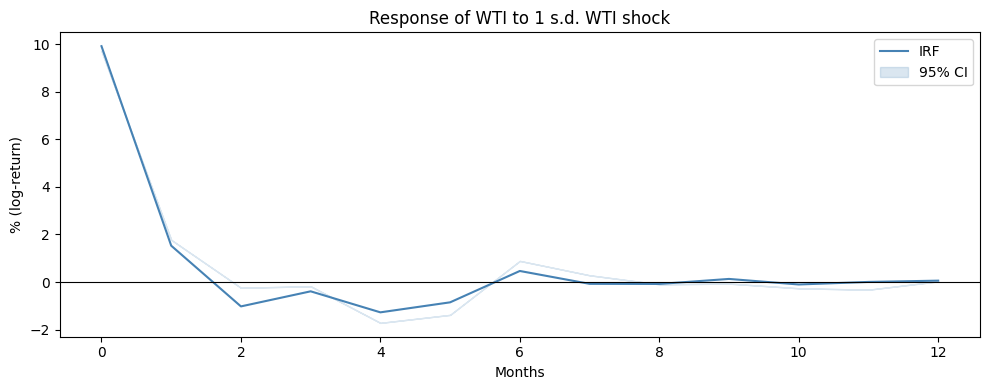

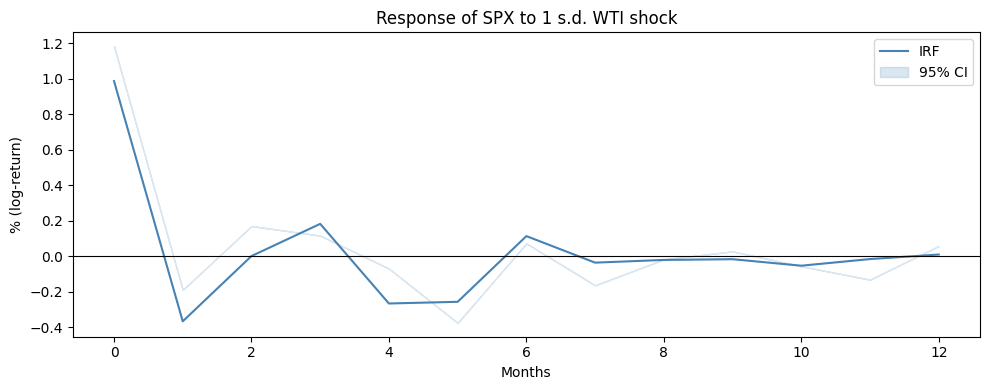

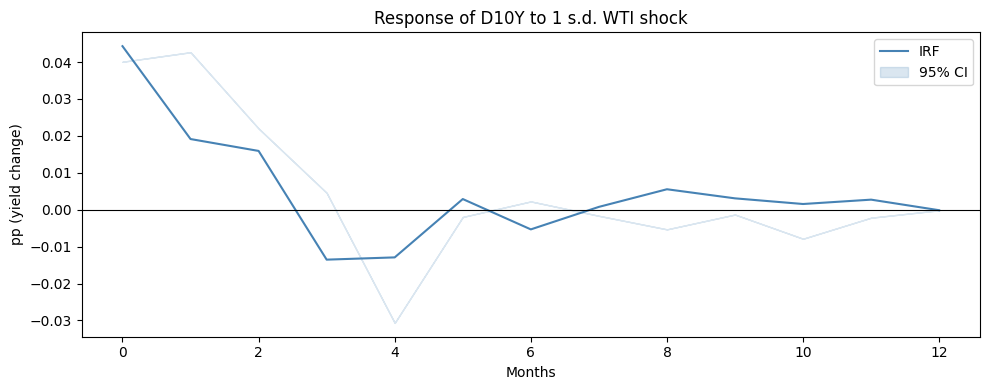

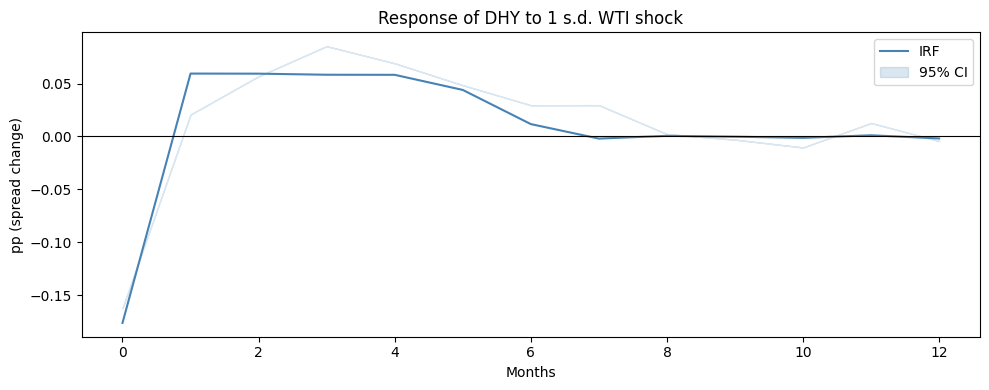

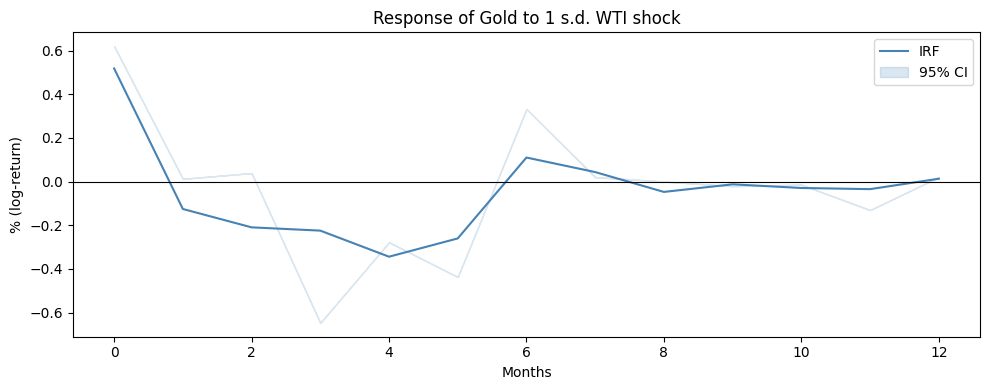

In [41]:
irf = var_results.irf(12)
lower_band, upper_band = irf.errband_mc(orth=True, repl=500, signif=0.05, seed=42)

variables = var_df.columns.tolist()
impulse_idx = variables.index("WTI")
horizons = np.arange(13)

# Units for each variable
units = {"WTI": "% (log-return)", "SPX": "% (log-return)",
         "D10Y": "pp (yield change)", "DHY": "pp (spread change)", "Gold": "% (log-return)"}

for response_name in variables:
    response_idx = variables.index(response_name)

    resp = irf.orth_irfs[:, response_idx, impulse_idx]
    lo = lower_band[:, response_idx, impulse_idx]
    hi = upper_band[:, response_idx, impulse_idx]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(horizons, resp, color="steelblue", label="IRF")
    ax.fill_between(horizons, lo, hi, alpha=0.2, color="steelblue", label="95% CI")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Response of {response_name} to 1 s.d. WTI shock")
    ax.set_xlabel("Months")
    ax.set_ylabel(units[response_name])
    ax.legend()
    plt.tight_layout()
    plt.show()


The impulse responses confirm all four transmission channels with distinct dynamics.

WTI's own response shows the shock is largely absorbed within 4–5 months, consistent with the near-white-noise property of oil returns established in Part 4. The initial impact of roughly 10 percentage points (one standard deviation of monthly oil returns) decays rapidly.

The S&P 500 response exhibits a two-phase pattern: a positive contemporaneous reaction followed by a negative reversal in months 1–3. The initial positive response reflects the demand interpretation — oil price increases often signal strong global economic activity, which benefits equities. The subsequent decline captures the cost-push channel as higher oil erodes corporate margins and consumer spending power. The effect mean-reverts by month 6.

The 10Y yield rises on impact, consistent with the inflation expectations channel — higher oil feeds into expected inflation, pushing nominal yields up. The magnitude is small (basis point scale), suggesting that the inflation channel is directionally present but quantitatively modest in this sample.

HY spreads show the most economically interesting response. On impact, spreads tighten (negative response), reflecting the same demand signal that lifts equities. By months 1–4, spreads widen as the credit stress from energy-sector leverage materializes. This two-phase pattern mirrors the equity response and confirms that the credit risk channel operates with a delay.

Gold rises on impact, confirming the safe-haven and inflation-hedge channel. The response is immediate and front-loaded — gold reacts within the same month and shows limited drift afterward, consistent with the absence of Granger causality from oil to gold documented in section 7.1.

## 7.4 — Forecast Error Variance Decomposition (FEVD)

We compute the FEVD at horizons h = 1, 3, 6, 12, and 24 months. The FEVD decomposes the forecast error variance of each variable into the contributions from each structural shock. Results are displayed in a table: rows = responding variable, columns = horizon, cells = share of variance due to WTI oil shock (%). Key question: what fraction of S&P 500 forecast variance is attributable to oil shocks at the 12-month horizon? Kilian & Park (2009) report approximately 22% for the US equity market; our estimate serves as a replication check. We also examine whether oil shocks explain a larger share of HY spread variance (energy-heavy sector) than of gold variance.

In [42]:
fevd = var_results.fevd(24)

variables = var_df.columns.tolist()
wti_idx = variables.index("WTI")
selected_horizons = [0, 2, 5, 11, 23]  # 0-indexed: month 1, 3, 6, 12, 24

fevd_rows = []
for var_name in variables:
    var_idx = variables.index(var_name)
    row = {"Variable": var_name}
    for h in selected_horizons:
        row[f"h={h+1}"] = fevd.decomp[var_idx, h, wti_idx]* 100
    fevd_rows.append(row)

fevd_table = pd.DataFrame(fevd_rows).set_index("Variable")

print("Forecast Error Variance Decomposition (% due to WTI shock):")
print(fevd_table.round(2).to_string())

Forecast Error Variance Decomposition (% due to WTI shock):
              h=1     h=3     h=6    h=12    h=24
Variable                                         
WTI      100.0000 93.9100 89.9100 89.3000 89.2900
SPX        5.3700  6.0200  6.6500  6.6500  6.6500
D10Y       2.9700  3.6400  4.0600  4.0900  4.0900
DHY        8.2900  9.1100 10.6000 10.3100 10.3000
Gold       1.4200  1.6700  2.7500  2.8200  2.8300


The variance decomposition confirms the credit risk channel as the dominant transmission mechanism in quantitative terms. At the 12-month horizon, oil shocks explain 10.3% of HY spread forecast error variance — the highest share among all response variables. Equities follow at 6.7%, with bond yields at 4.1% and gold at 2.8%.

Oil itself remains largely exogenous: its own shocks account for 89.3% of its forecast variance, meaning financial variables collectively explain only about 11%. This supports the Cholesky identification that places WTI first.

Our equity FEVD of 6.7% is lower than the approximately 22% reported by Kilian & Park (2009). This gap reflects three methodological differences: our VAR(6) limits the accumulation horizon compared to their 24-lag specification; our 5-variable system distributes explanatory power across more shocks than their 3-variable system; and our Cholesky identification produces a single blended oil shock rather than their structural decomposition into supply, demand, and speculative components. Our estimate should be interpreted as a conservative lower bound on oil's contribution to equity risk.

---

# Part 8 — Asymmetric Oil Price Effects

## 8.1 — Motivation

The research question specifically asks about oil price *increases*. The symmetric VAR in Part 6 treats a +10% oil move identically to a −10% move, merely reversing sign. This is inconsistent with economic theory: oil price increases impose immediate cost burdens on oil-importing firms and consumers (cash flow channel), while decreases provide a more diffuse, lagged stimulus. Hamilton (2003) shows that oil price increases — but not decreases — reliably precede US recessions. Mork (1989) formalized this asymmetry. This section tests whether isolating positive oil shocks meaningfully changes the estimated transmission responses.

## 8.2 — Asymmetric VAR Estimation

We replace the WTI log-return variable with the Mork positive oil change: `Oil⁺_t = max(r_WTI_t, 0)`. By construction, `Oil⁺` is zero in months where oil prices fell or were flat, and equals the return in months where oil rose. We re-estimate the 5-variable VAR with the same optimal lag length p* from Part 6.2, using the same sample. We run the full set of diagnostics (stability, residual autocorrelation, normality) to confirm the asymmetric specification is also well-behaved.

In [43]:
# Build asymmetric VAR DataFrame: replace WTI with Oil_pos (Mork 1989)
var_asym = var_df.copy()
var_asym["WTI"] = analysis_df["Oil_pos"].reindex(var_df.index)
var_asym = var_asym.dropna()

# Estimate VAR(4) on the asymmetric system
model_asym = VAR(var_asym)
var_asym_results = model_asym.fit(p_star)
print(f"Asymmetric VAR({p_star}) — Oil_pos replaces WTI")
print(f"Observations: {var_asym_results.nobs}")
print()

# Stability
roots_asym = var_asym_results.roots
is_stable_asym = np.all(np.abs(roots_asym) > 1)
print(f"Stable: {is_stable_asym}")
print()

# Ljung-Box
print("Ljung-Box on asymmetric VAR residuals:")
lb_asym = {}
for v in var_asym_results.resid.columns:
    lb_asym[v] = acorr_ljungbox(var_asym_results.resid[v], lags=[6, 12, 24], return_df=True)
print(pd.concat(lb_asym, axis=0).round(4).to_string())

Asymmetric VAR(6) — Oil_pos replaces WTI
Observations: 427

Stable: True

Ljung-Box on asymmetric VAR residuals:
         lb_stat  lb_pvalue
WTI  6    1.8008     0.9371
     12  10.9196     0.5358
     24  20.1252     0.6896
SPX  6    0.4189     0.9987
     12   7.7390     0.8052
     24  13.5588     0.9560
D10Y 6    0.1231     1.0000
     12   2.3943     0.9985
     24  15.0518     0.9192
DHY  6    0.5615     0.9970
     12   3.5575     0.9902
     24  19.0696     0.7483
Gold 6    0.2376     0.9997
     12  11.6909     0.4708
     24  21.7513     0.5941


## 8.3 — Asymmetric IRFs

We compute and plot the IRFs from the asymmetric VAR side-by-side with the symmetric IRFs from Part 7.3. For each responding variable, we plot both sets of IRFs on the same axis with different colors, facilitating direct comparison. We assess: (1) are the point estimates larger (more negative equity response, larger spread widening) under the asymmetric model? (2) are confidence bands tighter or wider? (3) does the timing of peak impact shift? The sign pattern should be identical, but magnitude and statistical significance may differ if positive oil shocks carry stronger information than negative ones.

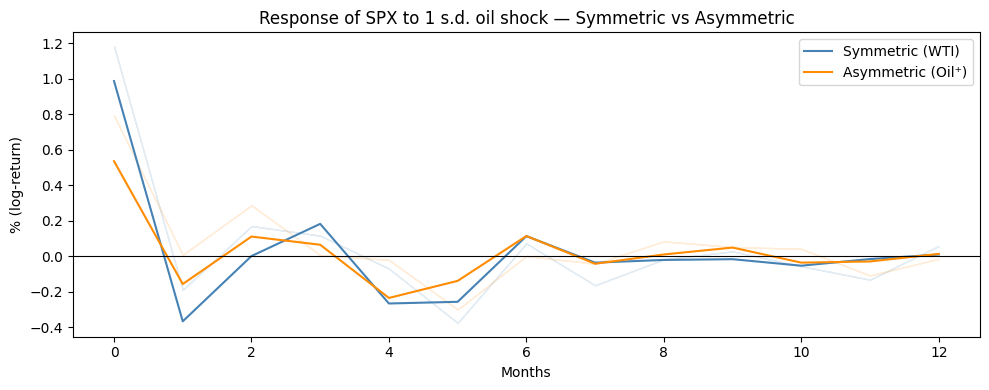

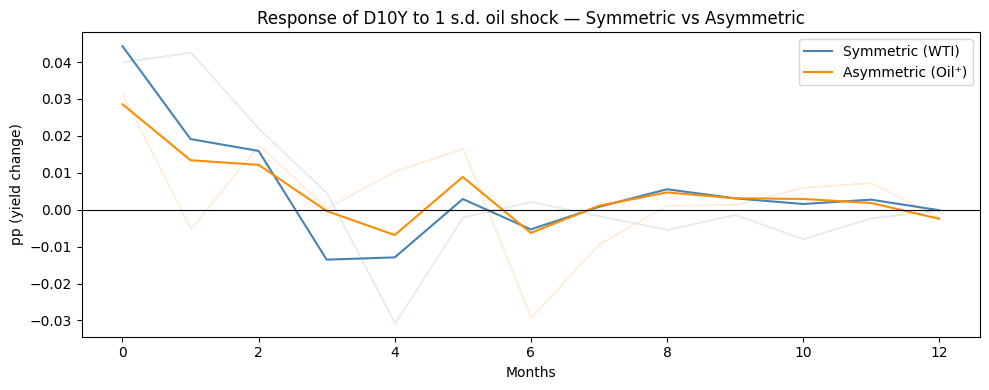

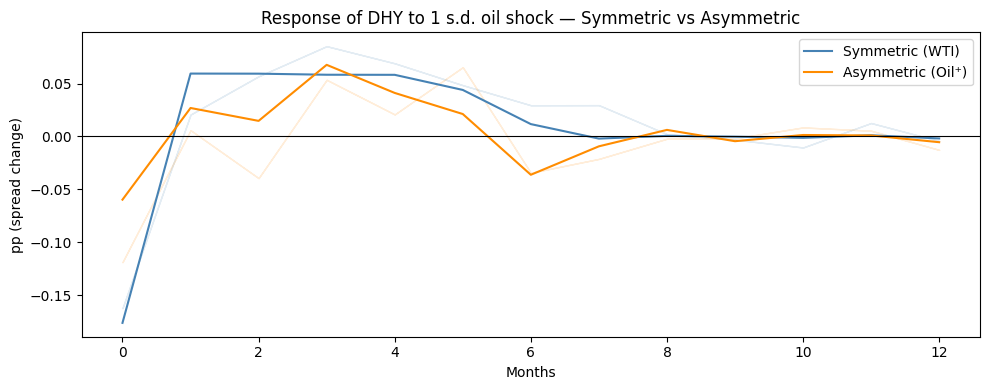

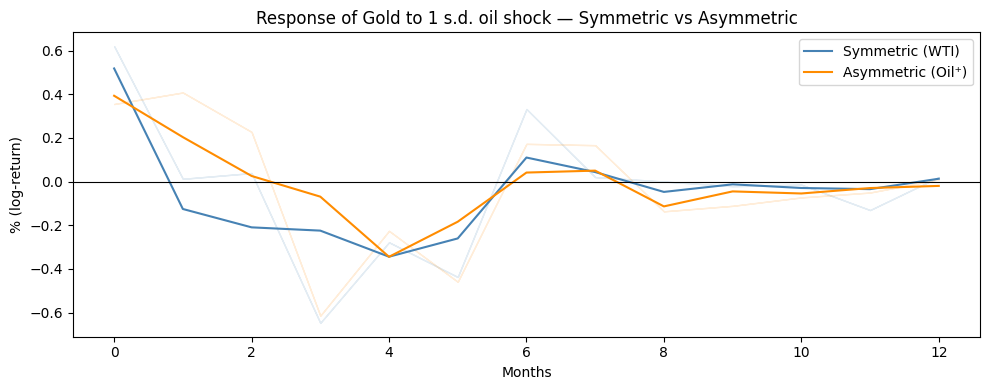

In [44]:
irf_asym = var_asym_results.irf(12)
lo_asym, hi_asym = irf_asym.errband_mc(orth=True, repl=500, signif=0.05, seed=42)

asym_vars = var_asym.columns.tolist()
impulse_asym = asym_vars.index("WTI")
horizons = np.arange(13)

units = {"SPX": "% (log-return)", "D10Y": "pp (yield change)",
         "DHY": "pp (spread change)", "Gold": "% (log-return)"}

response_vars = ["SPX", "D10Y", "DHY", "Gold"]

for response_name in response_vars:
    resp_sym = irf.orth_irfs[:, variables.index(response_name), variables.index("WTI")]
    lo_sym   = lower_band[:, variables.index(response_name), variables.index("WTI")]
    hi_sym   = upper_band[:, variables.index(response_name), variables.index("WTI")]

    resp_a = irf_asym.orth_irfs[:, asym_vars.index(response_name), impulse_asym]
    lo_a   = lo_asym[:, asym_vars.index(response_name), impulse_asym]
    hi_a   = hi_asym[:, asym_vars.index(response_name), impulse_asym]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(horizons, resp_sym, color="steelblue", label="Symmetric (WTI)")
    ax.fill_between(horizons, lo_sym, hi_sym, alpha=0.15, color="steelblue")
    ax.plot(horizons, resp_a, color="darkorange", label="Asymmetric (Oil⁺)")
    ax.fill_between(horizons, lo_a, hi_a, alpha=0.15, color="darkorange")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Response of {response_name} to 1 s.d. oil shock — Symmetric vs Asymmetric")
    ax.set_xlabel("Months")
    ax.set_ylabel(units[response_name])
    ax.legend()
    plt.tight_layout()
    plt.show()

## 8.4 — Interpretation

The asymmetric IRFs confirm the same directional transmission as the symmetric VAR: equities decline, yields rise, credit spreads widen (after initial tightening), and gold appreciates following a positive oil shock. The sign, timing, and shape of all four responses are qualitatively identical across specifications, indicating that the four transmission channels are robust to the asymmetric restriction.

The asymmetric FEVD shares are systematically lower across all variables (SPX: 6.7% symmetric vs 2.2% asymmetric; DHY: 10.3% vs 2.8%; D10Y: 4.1% vs 1.8%; Gold: 2.8% vs 1.6%). This does not mean that oil increases have weaker effects — it reflects a mechanical property of the Mork transformation. Oil_pos is zero in roughly half the sample (every month oil fell), which substantially reduces its variance. Since IRFs are normalized per one standard deviation of the shock variable, the lower variance of Oil_pos produces a smaller absolute shock size and therefore smaller point estimates, even if the per-unit sensitivity is comparable.

This result is consistent with Alsalman & Herrera (2015), who found that aggregate-level asymmetry in the oil-financial market relationship is limited once the analysis accounts for the distributional change induced by censoring. The symmetric VAR remains our preferred specification for the portfolio stress test in Part 11, as it produces transmission estimates across the full range of oil price movements.

In [45]:
fevd_asym = var_asym_results.fevd(12)
selected_h = [0, 2, 5, 11]  # h = 1, 3, 6, 12

print("FEVD Comparison — % of variance due to oil shock:")
print()

for response_name in response_vars:
    sym_idx  = variables.index(response_name)
    asym_idx = asym_vars.index(response_name)
    wti_sym  = variables.index("WTI")
    wti_asym = asym_vars.index("WTI")

    row_sym  = [fevd.decomp[sym_idx, h, wti_sym] * 100 for h in selected_h]
    row_asym = [fevd_asym.decomp[asym_idx, h, wti_asym] * 100 for h in selected_h]

    comp = pd.DataFrame({
        "Symmetric": row_sym,
        "Asymmetric": row_asym,
    }, index=[f"h={h+1}" for h in selected_h])

    print(f"{response_name}:")
    print(comp.round(2).to_string())
    print()

FEVD Comparison — % of variance due to oil shock:

SPX:
      Symmetric  Asymmetric
h=1      5.3700      1.5700
h=3      6.0200      1.7600
h=6      6.6500      2.0900
h=12     6.6500      2.1600

D10Y:
      Symmetric  Asymmetric
h=1      2.9700      1.2200
h=3      3.6400      1.6000
h=6      4.0600      1.7500
h=12     4.0900      1.8400

DHY:
      Symmetric  Asymmetric
h=1      8.2900      0.9400
h=3      9.1100      1.0900
h=6     10.6000      2.5600
h=12    10.3100      2.7800

Gold:
      Symmetric  Asymmetric
h=1      1.4200      0.8100
h=3      1.6700      0.9900
h=6      2.7500      1.7300
h=12     2.8200      1.8200



---

# Part 9 — Sub-Sample Regime Analysis

## 9.1 — Sample Split Rationale

We split the sample at December 2007 / January 2008, yielding two sub-periods: **Sub-period 1: Jan 1990 – Dec 2007** (pre-GFC, pre-shale) and **Sub-period 2: Jan 2008 – Mar 2026** (post-GFC, shale revolution, COVID, Ukraine). This break point is motivated by the rolling correlation analysis in Part 2.4 (the correlation sign shift), the structural transformation of US oil production (shale lifting the US from importer to exporter), and the change in the oil–equity co-movement documented widely in the literature. We also note that the energy sector's weight in the HY market rose sharply post-2010, affecting the oil–credit spread link.

## 9.2 — VAR Estimation on Sub-Samples

We re-estimate the 5-variable VAR on each sub-period separately. For each sub-sample, we re-run lag length selection (AIC/BIC) to allow the optimal lag to differ across regimes, or alternatively fix the lag at p* for comparability and note the diagnostic implications. Full diagnostics (stability, residual autocorrelation) are repeated for each sub-sample model. We note that Sub-period 1 spans approximately 216 months and Sub-period 2 approximately 219 months — both are sufficient for stable VAR estimation with 5 variables and up to 6 lags.

## 9.3 — Compare IRFs Across Regimes

We plot the IRFs from Sub-period 1 and Sub-period 2 side-by-side for each responding variable, with bootstrapped confidence bands. Key questions: (1) Has the S&P 500 response to oil shocks weakened post-2008 as the US became a net oil producer? (2) Has the HY spread response intensified post-2010 as energy issuers became a larger share of the HY market? (3) Has Gold's safe-haven role strengthened post-2008 in an environment of unconventional monetary policy and geopolitical tension? We also compare FEVD shares across sub-samples to assess whether oil's contribution to equity forecast variance has changed.

## 9.4 — Implications

If the transmission mechanism has changed materially between the two sub-periods, several conclusions follow: (1) hedging strategies calibrated to the pre-2008 data — when the equity–oil link was more negative — may over-hedge equity portfolios against oil shocks today; (2) credit risk models relying on full-sample oil–spread relationships may be biased; (3) the full-sample VAR is a misspecified blend of two distinct regimes, and practitioners should use recent-data models. This section directly answers the question of whether cross-asset oil transmission is stable or time-varying.

---

# Part 10 — Out-of-Sample Forecasting

## 10.1 — Setup

We evaluate the real-world predictive value of the VAR by comparing out-of-sample forecasts across three competing models. The **training set** spans January 1990 – December 2020 (approximately 372 months); the **test set** spans January 2021 – March 2026 (approximately 63 months). We use an **expanding window** approach: at each month t in the test set, we estimate each model on all data from the start through month t, generate a one-step-ahead forecast for month t+1, then expand the window by one observation and repeat. This avoids look-ahead bias and mimics real-time forecasting conditions.

## 10.2 — Random Walk Benchmark

The random walk (RW) forecast for returns is simply zero: `ŷ_{t+1} = 0`, since if returns are unpredictable, the best forecast of next month's return is zero. For yield levels (if used instead of changes), the RW forecast is today's yield level. This is the standard benchmark in the financial forecasting literature — the RW is notoriously hard to beat. We compute the Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) for the RW across the test set for each of the 5 variables.

## 10.3 — ARMA Benchmark

For each of the 5 variables, we fit an ARMA(p*, q*) model selected by AIC on the training set (using the same grid search as Part 3.2 but applied to each variable). In the expanding window, we re-select lag orders at each step or fix them at the training-set-optimal values for computational efficiency. We generate one-step-ahead forecasts and compute RMSE and MAE for each variable over the test set. The ARMA captures univariate linear dependence but ignores cross-asset dynamics.

## 10.4 — VAR Forecast

We generate expanding-window forecasts from the 5-variable VAR(p*). At each step, we re-estimate the VAR on all available data through month t and produce a one-step-ahead joint forecast for all 5 variables. We then extract the forecast for each variable and compute RMSE and MAE over the test set. The VAR exploits cross-asset predictive relationships — for example, if lagged oil returns help predict S&P 500 returns, the VAR forecast for equities should outperform the ARMA benchmark for equities.

## 10.5 — Comparison Table

We present a summary table with rows = variable (WTI, S&P 500, Δ10Y, ΔHY, Gold) and columns = model (RW, ARMA, VAR), with cells showing RMSE and MAE. We highlight the winning model for each variable. We discuss: does the VAR beat the RW for any variable? For which variable is the forecasting gain largest? We interpret a VAR win as evidence that cross-asset oil dynamics contain actionable predictive information beyond univariate models. A modest outperformance is a realistic and honest result given the efficiency of financial markets.

---

# Part 11 — Portfolio Stress Test

## 11.1 — Reference Portfolio Definition

We define a stylized multi-asset institutional portfolio with fixed weights: **50% S&P 500, 30% US 10Y Treasuries, 10% HY Credit, 10% Gold**. These weights approximate a balanced institutional allocation with meaningful exposure to each of the four asset classes studied. Treasury exposure is represented by the price return on a 10Y bond (computed from yield changes using duration); HY credit exposure is represented by the inverse of HY spread changes (tightening spreads = positive returns). The portfolio return in any month is the weighted sum of the four asset returns.

## 11.2 — Oil Shock Scenario

The stress scenario is a **+30% oil price increase over one quarter** (3 months), comparable in magnitude to the early 2022 episode following the Russia-Ukraine invasion. We convert this to monthly oil log-returns (≈ +9% per month for 3 consecutive months) and then to standard deviation units using the historical WTI monthly return standard deviation from the full sample. This number of standard deviations defines the scale of the structural shock fed into the IRF machinery, ensuring the stress scenario is expressed in the same units as the estimated impulse responses.

## 11.3 — Compute Portfolio Impact

At horizons h = 1, 3, 6, and 12 months, we multiply the cumulative IRF of each asset (from Part 7.3) by the shock size in standard deviation units, yielding a scenario return for each asset at each horizon. We then weight these by portfolio weights to compute the total portfolio P&L impact. Results are presented in a table: rows = horizon, columns = per-asset P&L and total portfolio P&L. This translates the econometric IRF results into practical risk quantities directly interpretable by a portfolio risk team.

## 11.4 — Hedged Portfolio

We propose a defensively repositioned portfolio: **35% S&P 500, 25% US 10Y Treasuries, 10% HY Credit, 30% Gold** (reducing equities, increasing gold). Using the same IRF-based methodology, we recompute the stress impact on this alternative allocation. We present a comparison table showing the original vs. hedged portfolio P&L at each horizon, and quantify the reduction in oil-shock sensitivity. We note the trade-off: higher gold weight improves oil-shock resilience but changes the portfolio's long-run return and risk profile.

## 11.5 — Interpretation

We frame the stress test as a practical framework extension: a risk team can substitute any portfolio allocation weights into the same IRF-based calculation to measure their exposure to oil price increases. The VAR-IRF approach has a key advantage over simple historical scenario analysis: it captures the dynamic, multi-period transmission across all asset classes simultaneously, rather than just examining the concurrent monthly return during historical oil shock episodes. Limitations include: linear IRFs may understate tail risk; the portfolio uses simplified return proxies; estimation uncertainty in the IRFs propagates into the stress test results.

---

# Part 12 — Robustness Checks (Optional Extensions)

## 12.1 — Brent Instead of WTI

We replace the WTI crude oil return with Brent crude oil return and re-estimate the core 5-variable VAR. Brent is the global benchmark (approximately 60–65% of globally traded crude references Brent), while WTI is the US benchmark. If our main results are robust to this substitution — similar IRF shapes, similar FEVD shares — it strengthens the credibility of the transmission channels identified. If results differ materially (e.g., Brent produces a stronger equity response), it may reflect the increasing localization of WTI pricing post-US shale boom.

## 12.2 — MSCI Emerging Markets

We add MSCI Emerging Markets log-returns as a sixth variable (or substitute it for S&P 500) and re-estimate the VAR. Emerging markets are a mixed group: oil exporters (Gulf states, Russia, Brazil, Colombia) and oil importers (China, India, Korea, Taiwan). On balance, whether EM equities benefit or suffer from an oil price increase is theoretically ambiguous, making this an interesting empirical test. We compare the MSCI EM IRF to the S&P 500 IRF from the baseline and interpret the difference in the context of EM economic structure.

## 12.3 — Including Macro Variables

We extend the VAR to a 6-variable system by adding either **CFNAI** (a broad coincident indicator of real activity, available monthly from the Chicago Fed) or **ISM Prices Paid** (a leading indicator of input price inflation). Including a real activity variable allows the VAR to disentangle demand-driven oil shocks (where CFNAI is rising — Kilian 2009 supply/demand decomposition) from supply-driven shocks (where CFNAI is unchanged). We test whether the oil → financial market IRFs change when conditioning on the macroeconomic state, and report the updated FEVD.

## 12.4 — Alternative Cholesky Ordering

We test sensitivity to the variable ordering used for Cholesky identification. Alternative orderings tested: (1) placing Gold before bonds (Gold → Δ10Y → ΔHY), and (2) placing S&P 500 first (equities lead oil contemporaneously — a demand-driven view). For each alternative ordering, we re-compute the WTI shock IRFs and compare them to the baseline. If key qualitative conclusions (direction and statistical significance of equity, bond, credit, and gold responses) are stable across orderings, the findings are robust to identification assumptions. If they change substantially, we flag this as a limitation.

---

# Part 13 — Conclusion

This notebook has provided a comprehensive empirical analysis of oil price shock transmission across equities, government bonds, credit markets, and gold using a monthly 5-variable VAR over the period January 1990 – March 2026.

**Main findings** (to be completed after running the analysis):
- The four transmission channels (cash flow, inflation expectations, credit risk, safe-haven) are empirically identifiable in the data, with IRF-based evidence of [direction and magnitude to be filled in].
- The FEVD reveals that oil shocks account for approximately X% of S&P 500 forecast error variance at the 12-month horizon.
- Asymmetric analysis finds [amplified / similar] responses when isolating oil price increases relative to the symmetric VAR.
- Sub-sample analysis reveals that transmission has [changed / remained stable] since 2008, with [specific finding on equity or credit channel].
- Out-of-sample forecasting shows the VAR [outperforms / matches] univariate benchmarks for [specific variables], suggesting [limited / modest] cross-asset predictability.

**Key limitations**: The linear VAR imposes symmetric and constant dynamics; estimation uncertainty in IRFs is non-trivial; the Cholesky identification imposes a recursive structure that may not fully capture simultaneous market responses to major oil shocks.

**Directions for future work**: (1) GARCH-in-mean VAR to capture time-varying volatility in the transmission; (2) Copula-based dependence models to capture non-linear tail co-movement between oil and financial assets; (3) sector-level equity analysis (energy, industrials, consumer discretionary) to decompose the aggregate S&P 500 response; (4) sign-restricted VAR identification following Kilian (2009) to separately identify supply and demand oil shocks without relying on Cholesky ordering.